# Task 3 - `gender` and `usage`

COSC2753 Assignment 2 - group SG_G3

The brief asks for a system that predicts **both** `gender` and `usage`. It does
not say whether that is one model or two, which is the interesting part: that
choice is the design decision this notebook is built to answer with evidence
rather than preference.

**What is compared**

| | design | backbones | outputs |
|---|---|---|---|
| **A** | two independent models | 2 | 5 - 8 |
| **B** | one model, joint label | 1 | 24 `gender x usage` pairs that occur |
| **C** | one shared backbone, two heads | 1 | 5 + 8 |

Identical convolutional body, identical seed, identical schedule. The only thing
that changes between A, B and C is how the two labels are attached to it, so the
difference between them **is** the effect of that choice and nothing else.

**Three further questions, each one variable at a time**

1. does class-weighted loss help the long tail, or just trade the head for it?
2. does the externally collected data help? (it is predicted to *hurt* `usage` -
   see section 7, and the prediction is recorded here before the run)
3. how much of the score survives a split that mimics the real test set?

**Metric.** macro-F1 throughout. Accuracy is reported beside it only to show why
it must not be used: predicting `Casual` for every row scores **76.7%** accuracy
on `usage` and a macro-F1 of **0.109**.

### Task 3 investigation flow

![Task 3 investigation flow](figures/00_task3_investigation_flow.svg)

*Figure 1. Target analysis, controlled model comparison and increasingly difficult evaluations lead to one deployment-aware decision. Original schematic based on the evidence generated in this notebook.*

Preprocessing leaves two targets with very different difficulty. `gender` has enough examples in every class, while four `usage` classes together contain only **94 rows**. The investigation therefore starts with the data constraint, holds the split and training protocol fixed, and changes one modelling decision at a time. Later tests deliberately move away from the random validation distribution before the final model is selected.


### Where to find each model, and the judgement

| | section |
|---|---|
| baselines (majority, 1-NN on pixels) | section 3 |
| design **A** - two independent models | section 5 |
| design **B** - one joint `gender x usage` label | section 5 |
| design **C** - one shared body, two heads | section 5 |
| C + class-weighted loss | section 6 |
| C + external data | section 7 |
| design **D** - transfer from `articleType` | section 10.3 |
| C + logit adjustment / mirror TTA | section 10.1, section 10.2 |
| every model in one table | section 10.4 |
| **ultimate judgement** | **Section 11** |

Architecture and every hyper-parameter are tabulated in section 4. Two harder evaluations
than the random split - a forward split by id, and 261 independently photographed
items - are in section 8. Exploratory data analysis for the shared dataset lives in the
team's `notebooks/00_eda_and_preprocessing.ipynb` and is not duplicated here.

## 0 - Setup

Runs on Colab or locally. On Colab, mount Drive first; the cell below finds the
data wherever it ended up.

In [1]:
import os, sys, json, time, math, random, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

SEED = 42
IMAGE_SIZE = (60, 80)          # width, height - the provided dataset's exact size
TARGETS = ["gender", "usage"]

# QUICK=True runs everything end to end in a few minutes on a smaller sample, to
# prove the notebook works before spending an hour on the real numbers.
QUICK = False
# Headless smoke test: A2_QUICK=1 flips this without editing the file, so a CI-style
# run (python task3_build.py, or nbconvert --execute) can prove the pipeline works
# before committing an hour of GPU. On Colab, ignore this and edit the line above.
if os.environ.get("A2_QUICK") == "1":
    QUICK = True
EPOCHS = 6 if QUICK else 20
SAMPLE = 4000 if QUICK else None

random.seed(SEED); np.random.seed(SEED)

# A fingerprint of the code cells, recorded at the run that produced the outputs. Its whole job is to make a
# stale upload obvious in the first five seconds: the handover note says which BUILD
# to expect, so a notebook that is a regeneration behind announces itself here rather
# than failing seventy minutes later. "dev" means running the .py directly.
BUILD = "00550b6d"
print(f"colab={IN_COLAB}  quick={QUICK}  epochs={EPOCHS}  BUILD={BUILD}")

colab=False  quick=False  epochs=20  BUILD=00550b6d


### 0.1 Staging the data - Colab only, skipped locally

Reading 37,745 individual JPEGs through the Drive mount is the slowest thing in
this notebook: every file is a separate API call, so it costs roughly half an hour
*per session*. Copying one zip and unpacking it onto Colab's local disk turns that
into about a minute.

Set the two paths below to match your Drive. A shortcut in *My Drive* pointing at a
Shared Drive works fine - Colab mounts My Drive only, so the shortcut is the bridge.

Re-running is cheap: if the data is already unpacked, this does nothing.

In [2]:
# Searched in order, first hit wins. The zip has lived in both places across runs and
# hardcoding one of them is what broke the first Colab attempt, so both are tried.
COLAB_ZIP_CANDIDATES = [
    "/content/drive/MyDrive/A2_ExternalData/ColabDataset.zip",
    "/content/drive/MyDrive/ColabDataset.zip",
]
EXTERNAL_ON_DRIVE = "/content/drive/MyDrive/A2_ExternalData"

if IN_COLAB:
    import shutil
    import subprocess

    marker = "preprocessed_datasets/train/styles_train.csv"
    roots = [Path("/content"), Path("/content/ColabDataset")]

    if not any((r / marker).exists() for r in roots):
        src = next((Path(c) for c in COLAB_ZIP_CANDIDATES if Path(c).exists()), None)
        if src is None:
            listing = "\n  ".join(sorted(p.name for p in Path("/content/drive/MyDrive").iterdir()))
            raise FileNotFoundError(
                "none of these exist:\n  " + "\n  ".join(COLAB_ZIP_CANDIDATES)
                + f"\nMy Drive contains:\n  {listing}\n"
                "Add the real path to COLAB_ZIP_CANDIDATES above.")
        print(f"copying {src.stat().st_size / 1e6:.0f} MB from Drive ...")
        shutil.copy(src, "/content/_data.zip")
        # -o overwrites without asking. Without it a re-run stops on a 'replace?'
        # prompt that Colab has no way to answer, and the cell hangs silently.
        subprocess.run(["unzip", "-qo", "/content/_data.zip", "-d", "/content/"], check=True)
        print("unpacked")

    root = next((r for r in roots if (r / marker).exists()), None)
    if root is None:
        raise FileNotFoundError(f"unpacked, but no {marker} under {[str(r) for r in roots]}")
    os.environ["A2_COLAB_DATASET"] = str(root)

    if Path(EXTERNAL_ON_DRIVE).is_dir():
        os.environ["A2_EXTERNAL_DATA"] = EXTERNAL_ON_DRIVE

    # Verify the unpack finished. A truncated unzip otherwise fails ten minutes later,
    # in the middle of image decoding, with an error that points somewhere else.
    n_img = len(list((root / "preprocessed_datasets/train/images_train").glob("*.jpg")))
    n_csv = len(pd.read_csv(root / marker))
    print(f"train images {n_img:,} | csv rows {n_csv:,}")
    assert n_img == n_csv, (
        f"{n_csv - n_img} images missing -- the unzip was incomplete. "
        "Delete /content/preprocessed_datasets and re-run this cell.")
    print("data staged OK")
else:
    print("not on Colab - using local paths")

not on Colab - using local paths


### 0.2 Finding the data

Two datasets are involved and they are **not** the same thing:

* **the provided catalogue** - `ColabDataset`, the course-provided
  training data de-duplicated: 38,617 -> 37,745 rows.
* **the externally collected images** - `A2_ExternalData`, added to *training
  only* in section 7.

On Colab a folder someone shared with you sits under *Shared with me*, which is
**not mounted**. Right-click it in Drive -> **Add shortcut to Drive** first.

In [3]:
def _first_dir(candidates, must_contain=None):
    """Return the first candidate that exists (and holds `must_contain`)."""
    tried = []
    for c in candidates:
        c = Path(c); tried.append(str(c))
        if c.is_dir() and (must_contain is None or (c / must_contain).exists()):
            return c
    raise FileNotFoundError(
        "not found. Tried:\n  " + "\n  ".join(tried)
        + "\n\nOn Colab: 'Shared with me' is NOT mounted - right-click the folder in "
          "Drive, 'Add shortcut to Drive', then re-run."
    )

def _first_path(candidates, kind):
    """First candidate that exists, as a file or a directory."""
    tried = []
    for c in candidates:
        c = Path(c); tried.append(str(c))
        if (c.is_file() if kind == "file" else c.is_dir()):
            return c
    raise FileNotFoundError(
        "not found. Tried:\n  " + "\n  ".join(tried)
        + "\n\nIn a repository checkout the data belongs in datasets/ -- see the "
          "README's dataset section.\nOn Colab: 'Shared with me' is NOT mounted - "
          "right-click the folder in Drive, 'Add shortcut to Drive', then re-run."
    )


def _repo_root():
    """Nearest ancestor holding pyproject.toml, so a checkout finds its own data."""
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (base / "pyproject.toml").is_file():
            return base
    return Path("/nonexistent")


# The table and the images are resolved separately because a checkout and the Colab
# bundle disagree about where each one lives: the repository keeps the audited
# 37,847-row manifest under preprocessed_datasets/ and the JPEGs under datasets/,
# while the Colab zip keeps both under preprocessed_datasets/train/. Resolving the
# pair independently is what lets one notebook serve both without a rename.
_REPO = _repo_root()

# A2_DATA_ROOT is the variable the README documents and src/data_paths.py honours, so
# it has to work here too: a machine keeping the images on another drive sets it once,
# not once per notebook. A2_TRAIN_TABLE and A2_TRAIN_IMAGES stay for pointing the two
# halves at different places, which the Colab layout occasionally needs.
_DATA_ROOT = Path(os.environ.get("A2_DATA_ROOT", "/nonexistent"))

TRAIN_CSV = _first_path([
    os.environ.get("A2_TRAIN_TABLE", "/nonexistent"),
    _DATA_ROOT / "train" / "styles_train.csv",
    _DATA_ROOT / "preprocessed_datasets" / "train" / "styles_train.csv",
    _REPO / "preprocessed_datasets" / "train_manifest.csv",
    _REPO / "datasets" / "train" / "styles_train.csv",
    _REPO / "datasets" / "FashionDataset" / "train" / "styles_train.csv",
    "/content/preprocessed_datasets/train/styles_train.csv",
    "/content/ColabDataset/preprocessed_datasets/train/styles_train.csv",
    "/content/drive/MyDrive/ColabDataset/preprocessed_datasets/train/styles_train.csv",
], "file")

TRAIN_IMG = _first_path([
    os.environ.get("A2_TRAIN_IMAGES", "/nonexistent"),
    _DATA_ROOT / "train" / "images_train",
    _DATA_ROOT / "preprocessed_datasets" / "train" / "images_train",
    _REPO / "datasets" / "train" / "images_train",
    _REPO / "datasets" / "FashionDataset" / "train" / "images_train",
    _REPO / "preprocessed_datasets" / "train" / "images_train",
    "/content/preprocessed_datasets/train/images_train",
    "/content/ColabDataset/preprocessed_datasets/train/images_train",
    "/content/drive/MyDrive/ColabDataset/preprocessed_datasets/train/images_train",
], "dir")

try:
    EXTERNAL_ROOT = _first_dir([
        os.environ.get("A2_EXTERNAL_DATA", "/nonexistent"),
        # Dataset/ is where src/external_data.py unpacks the Drive folder, so Task 3
        # and the external-data module agree on one location in a checkout.
        _REPO / "Dataset",
        _REPO / "datasets" / "external",
        _REPO / "datasets" / "A2_ExternalData",
        "/content",
        "/content/A2_ExternalData",
        "/content/drive/MyDrive/A2_ExternalData",
    ], must_contain="ExternalCosmetics")
except FileNotFoundError as exc:
    EXTERNAL_ROOT = None
    print("external data not found - section 7 will be skipped\n", exc)

print("catalogue :", TRAIN_CSV)
print("images    :", TRAIN_IMG)
print("external  :", EXTERNAL_ROOT)

### 0.3 The frame, and the split rule

`ColabDataset` ships the raw catalogue columns, so `filename`, `path` and
`group_id` are added here. `group_id = id` is correct **because** this file is
already one row per product - the de-duplication that produced it is what makes
the assumption safe, and the assertion below is what checks it rather than
trusting it.

The split function is copied verbatim from `src/preprocessing.make_split` so the
split matches the rest of the team's (rule 2 in the repo README) without needing
to clone the private repo inside Colab. If `src/` happens to be importable, the
real one is used instead and the two are checked to agree.

In [4]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = SEED

def make_split(frame, target, validation_share=0.2, random_state=RANDOM_STATE):
    """Copy of src/preprocessing.make_split - whole groups stay on one side."""
    if target not in frame.columns:
        raise KeyError(f"{target!r} is not a column of the frame passed in.")
    frame = frame.loc[frame[target].notna()].reset_index(drop=True)
    if frame.empty:
        raise ValueError(f"No rows carry a {target!r} label.")
    assert frame["group_id"].is_unique, "multi-row group_id values found"

    group_label = frame.groupby("group_id")[target].agg(
        lambda v: v.value_counts().index[0])
    counts = group_label.value_counts()
    splittable = group_label[~group_label.isin(counts[counts < 2].index)]

    _, validation_groups = train_test_split(
        splittable.index, test_size=validation_share,
        stratify=splittable.values, random_state=random_state)
    is_val = frame["group_id"].isin(set(validation_groups))
    return (frame.loc[~is_val].reset_index(drop=True),
            frame.loc[is_val].reset_index(drop=True))


def make_split_forward(frame, target, validation_share=0.2):
    """Hold out the HIGHEST ids instead of a random draw.

    The graded test set is the 5,829 highest ids, so the real task is extrapolation
    forward along a catalogue that was added to over time, not interpolation inside
    a shuffled pool. A random split silently assumes the two are the same. Section 8
    measures how far apart they actually are.
    """
    frame = frame.loc[frame[target].notna()].sort_values("id").reset_index(drop=True)
    cut = int(len(frame) * (1 - validation_share))
    return frame.iloc[:cut].reset_index(drop=True), frame.iloc[cut:].reset_index(drop=True)


frame = pd.read_csv(TRAIN_CSV)
frame["filename"] = frame["id"].astype(str) + ".jpg"
frame["path"] = frame["filename"].map(lambda n: str(TRAIN_IMG / n))
frame["group_id"] = frame["id"].astype(str)
assert frame["group_id"].is_unique, "ColabDataset is meant to be one row per product"

if SAMPLE:
    frame = frame.sample(SAMPLE, random_state=SEED).reset_index(drop=True)

print(f"{len(frame):,} rows, {frame['articleType'].nunique()} articleTypes")
print(frame[["id", "gender", "usage", "articleType"]].head(3).to_string(index=False))

37,745 rows, 121 articleTypes
  id gender  usage articleType
1163    Men Sports     Tshirts
1164    Men Sports     Tshirts
1525 Unisex Casual   Backpacks


## 1 - Target and class-distribution analysis

Before any model: the two targets look like one task but behave like two very
different ones, and every design decision later follows from this section.

In [5]:
def class_table(frame, col):
    vc = frame[col].value_counts()
    out = pd.DataFrame({"n": vc, "share %": (100 * vc / len(frame)).round(2)})
    out.index.name = col
    return out

for col in TARGETS:
    t = class_table(frame, col)
    ratio = t["n"].max() / t["n"].min()
    print(f"=== {col} - {len(t)} classes, imbalance {ratio:,.0f}x ===")
    print(t.to_string(), "\n")

=== gender - 5 classes, imbalance 43x ===
            n  share %
gender                
Men     20549    54.44
Women   14069    37.27
Unisex   2055     5.44
Boys      589     1.56
Girls     483     1.28 

=== usage - 8 classes, imbalance 28,968x ===
                  n  share %
usage                       
Casual        28968    76.75
Sports         3914    10.37
Ethnic         2565     6.80
Formal         2204     5.84
Smart Casual     55     0.15
Travel           25     0.07
Party            13     0.03
Home              1     0.00 



`gender` has five classes and the smallest holds **483** images. `usage` has
eight and the smallest holds **one**. They are not two instances of the same
problem; `gender` is a learnable imbalanced problem and `usage` is a long tail
with classes that cannot be learned from the data at all.

### 1.1 The ceiling this puts on macro-F1

macro-F1 averages over classes, so a class that can never be predicted
contributes a hard zero and caps the score no matter how good the model is.

In [6]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    for thr in (2, 10, 30, 100):
        dead = int((vc < thr).sum())
        rows.append({"target": col, "classes with fewer than": thr,
                     "such classes": f"{dead}/{len(vc)}",
                     "macro-F1 ceiling": round(1 - dead / len(vc), 3)})
ceiling = pd.DataFrame(rows)
print(ceiling.to_string(index=False))

target  classes with fewer than such classes  macro-F1 ceiling
gender                        2          0/5             1.000
gender                       10          0/5             1.000
gender                       30          0/5             1.000
gender                      100          0/5             1.000
 usage                        2          1/8             0.875
 usage                       10          1/8             0.875
 usage                       30          3/8             0.625
 usage                      100          4/8             0.500


Read the `usage` rows carefully. **Four of its eight classes have under 100
training images** - `Home` 1, `Party` 13, `Travel` 25, `Smart Casual` 55. If
those four are unlearnable then macro-F1 cannot exceed **0.500**, and a reported
0.5 would mean the model got *everything else perfect*.

This is the single most important fact about Task 3, and it says the interesting
work is not architecture search - it is what to do about four classes that the
data does not contain enough of to teach.

### 1.2 Evaluation metric

In [7]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    p = vc.iloc[0] / len(frame)
    # every class but the majority scores F1 = 0; the majority scores 2p/(1+p)
    rows.append({"target": col, "majority class": vc.index[0],
                 "accuracy": f"{100 * p:.1f}%",
                 "macro-F1": round(2 * p / (1 + p) / len(vc), 3)})
print("predicting the majority class and nothing else:\n")
print(pd.DataFrame(rows).to_string(index=False))

predicting the majority class and nothing else:

target majority class accuracy  macro-F1
gender            Men    54.4%     0.141
 usage         Casual    76.7%     0.109


A model that has learned *nothing* scores 76.7% accuracy on `usage`. Any accuracy
figure below that is worse than useless, and any figure near it says nothing at
all. Every number from here on is macro-F1; accuracy is shown alongside only as
evidence of this gap.

### 1.3 Macro-F1 conventions

`usage` has classes that can vanish from validation entirely (`Home` has one image
in the whole training set, so a grouped split puts it in train and nowhere else).
Macro-F1 gives equal weight to every class rather than every row [1]. When a class vanishes from validation, the two usual conventions disagree:

| | denominator | what it says |
|---|---|---|
| `macro_f1` | **all 8** classes | a label we cannot predict scores 0 - an honest description of the task |
| `macro_f1_in_val` | classes **present in validation** (7) | sklearn's default when `labels=` is not passed |

Eight versus seven is a **~14% difference on the same predictions**, and neither
number is wrong. So every result below carries both, with the denominator printed
next to it.

This matters for more than tidiness: a teammate's Task 3 figures are reported as
*"combined val macro-F1"* - 0.6312 for the combined-recipe CNN (gender 0.78,
`usage` 0.49) and 0.6563 for BBN (`usage` 0.55). Putting a number from this
notebook beside those is only meaningful if three things match: the **denominator**
above, the **split**, and whether "combined" means the mean of the two targets.
Confirm all three before claiming one approach beat another.

## 2 - Multi-output design choice

The brief leaves this open. It is tempting to settle it by training both and
keeping the winner, but that answers "which scored higher on this seed", not
"which is the right design". Two properties of the data decide it in advance,
and the training runs in section 5 then test the prediction. Multi-task learning can improve generalisation through a shared representation, but sharing is useful only when the tasks provide compatible signals [2], [3].

In [8]:
g = sorted(frame["gender"].dropna().unique())
u = sorted(frame["usage"].dropna().unique())
tab = (frame.pivot_table(index="gender", columns="usage", values="id", aggfunc="count")
       .reindex(index=g, columns=u).fillna(0).astype(int))
occurring = int((tab > 0).sum().sum())

print(f"{len(g)} gender x {len(u)} usage = {len(g) * len(u)} possible pairs")
print(f"pairs that occur: {occurring}   ->   {len(g) * len(u) - occurring} never occur\n")
print(tab.to_string())

joint = frame.groupby(["gender", "usage"]).size().sort_values()
tiny = joint[joint < 10]
print(f"\njoint classes with fewer than 10 rows: {len(tiny)} of {occurring}")
print(tiny.to_string())

5 gender x 8 usage = 40 possible pairs
pairs that occur: 24   ->   16 never occur

usage   Casual  Ethnic  Formal  Home  Party  Smart Casual  Sports  Travel
gender                                                                   
Boys       559      10       0     0      0             0      20       0
Girls      474       8       0     0      0             0       1       0
Men      15452      90    2098     0      0            44    2864       1
Unisex    1756       0       1     1      0             0     277      20
Women    10727    2457     105     0     13            11     752       4

joint classes with fewer than 10 rows: 6 of 24
gender  usage 
Girls   Sports    1
Unisex  Home      1
        Formal    1
Men     Travel    1
Women   Travel    4
Girls   Ethnic    8


**Property 1 - a joint label multiplies the sparsity.** `usage` alone has one
class under 10 images. Crossed with `gender` it has six. A combined model does
not merely inherit the long tail, it lengthens it.

**Property 2 - the two labels barely inform each other.** If knowing `gender`
told you most of `usage`, a joint label would be capturing a real structure and
the extra sparsity might be worth paying for. Measured as entropy:

In [9]:
def H(series):
    p = series.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

def H_cond(frame, target, given):
    return float(sum(len(grp) / len(frame) * H(grp[target])
                     for _, grp in frame.groupby(given)))

rows = []
for t, given in [("usage", "gender"), ("gender", "usage"),
                 ("usage", "articleType"), ("gender", "articleType"),
                 ("usage", "subCategory"), ("gender", "subCategory")]:
    h, hc = H(frame[t]), H_cond(frame, t, given)
    rows.append({"target": t, "knowing": given, "H (bits)": round(h, 3),
                 "H | knowing": round(hc, 3),
                 "uncertainty removed": f"{100 * (1 - hc / h):.1f}%"})
print(pd.DataFrame(rows).to_string(index=False))

target     knowing  H (bits)  H | knowing uncertainty removed
 usage      gender     1.160        1.026               11.5%
gender       usage     1.411        1.277                9.5%
 usage articleType     1.160        0.385               66.8%
gender articleType     1.411        0.803               43.1%
 usage subCategory     1.160        0.921               20.6%
gender subCategory     1.411        1.186               15.9%


Knowing `gender` removes **11.5%** of the uncertainty in `usage`, and knowing
`usage` removes **9.5%** of the uncertainty in `gender`. Nearly independent. So
design **B** pays a large, measurable cost in sparsity to capture very little.

**The same table also argues for design C.** `articleType` removes **66.8%** of
the uncertainty in `usage` and **43.1%** in `gender` - far more than either
target tells you about the other. The two tasks are not related to each other
directly; they are both largely determined by a third thing, *what the garment
is*, which is exactly what a convolutional backbone can see. That is a concrete
reason to expect a **shared backbone with separate heads** to work: the sharing
should happen in the features, not in the label.

> **Prediction recorded before training:** C ~ A > B, with B losing most on
> `usage` macro-F1. Section 5 either confirms this or the reasoning above is wrong, and
> both outcomes are worth reporting.

### Research basis: hard parameter sharing

![Hard parameter sharing from Ruder](figures/research/ruder_hard_parameter_sharing_fig1.png)

*Research figure. Hard parameter sharing keeps a common feature extractor and gives
each task its own output layers. Reproduced from Fig. 1 of Ruder [3].*

In hard parameter sharing, all targets update the same hidden representation, while
each target keeps a separate prediction head [2], [3]. The attraction is both
statistical and practical: related tasks can regularise the shared features, and one
backbone is evaluated instead of two. The risk is **negative transfer**. If the two
losses prefer different features, their gradients compete and a shared model can be
worse than two independent models.

Design C is exactly this structure: garment pixels pass through one convolutional
body, then branch into `gender` and `usage`. It fits this dataset as a hypothesis
because both labels depend on visible garment properties, but the low mutual
information measured above makes negative transfer plausible. That is why A is kept
as a controlled alternative rather than assuming that parameter sharing must help.

### Model designs

![Three Task 3 model designs](figures/01_multitask_designs.svg)

*Figure 2. A duplicates the feature extractor, B merges both targets into one sparse label, and C shares visual features while keeping separate decisions. Original schematic based on the architectures implemented below.*

The diagram makes the trade-off explicit. Design A protects each target from interference but duplicates almost the whole network. Design B is compact but turns the existing long tail into missing joint classes. Design C adds the second output for only **1,032 parameters**, which makes it the most efficient candidate if its loss in predictive performance remains smaller than the gain obtained from tail weighting.


## 3 - Baselines

Two floors. Nothing below these counts as having learned anything.

* **majority** - predict the most common class. Bounds *accuracy*.
* **1-NN on downscaled pixels** - no training, no parameters. Bounds *macro-F1*:
  whatever this scores is available from raw pixel similarity alone, so a CNN
  that does not beat it has not earned its complexity.

In [10]:
from PIL import Image, ImageOps

def load_images(paths, size=IMAGE_SIZE, cache=None):
    """Decode once into one uint8 array. Re-reading JPEGs every epoch off Drive is
    the slowest thing in this notebook; 37,745 x 80 x 60 x 3 is only ~543 MB."""
    if cache is not None and Path(cache).exists():
        arr = np.load(cache)
        if len(arr) == len(paths):
            print(f"loaded {len(arr):,} images from cache {cache}")
            return arr
    out = np.zeros((len(paths), size[1], size[0], 3), dtype=np.uint8)
    t0, padded = time.time(), 0
    for i, p in enumerate(paths):
        with Image.open(p) as im:
            im = ImageOps.exif_transpose(im).convert("RGB")
            if im.size != size:
                # Pad on white rather than stretch: the catalogue background is white
                # and the portrait aspect ratio carries class cues top and bottom.
                im = ImageOps.pad(im, size, method=Image.Resampling.BILINEAR,
                                  color=(255, 255, 255), centering=(0.5, 0.5))
                padded += 1
            out[i] = np.asarray(im)
        if i and i % 5000 == 0:
            print(f"  {i:,}/{len(paths):,}  ({time.time() - t0:.0f}s)")
    print(f"decoded {len(out):,} images in {time.time() - t0:.0f}s "
          f"({padded} were not {size[0]}x{size[1]} and were padded)")
    if cache is not None:
        np.save(cache, out)
    return out

# The decoded array is ~543 MB, so it is cached rather than rebuilt every run. It goes
# to /content on Colab (local disk, not Drive) and to the gitignored artifacts/ tree in
# a checkout; the directory is created before decoding starts.
import tempfile

_CACHE_DIR = (Path("/content") if IN_COLAB
              else (_REPO / "artifacts" / "task3" if _REPO.is_dir()
                    else Path(tempfile.gettempdir())))
_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE = _CACHE_DIR / "train_images.npy"
X_all = load_images(frame["path"].tolist(), cache=None if SAMPLE else CACHE)
print("image array:", X_all.shape, f"{X_all.nbytes / 1e6:.0f} MB")

In [11]:
# Positional index so a split frame can address rows of X_all without re-decoding.
frame["_row"] = np.arange(len(frame))

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def score(y_true, y_pred, labels=None):
    """Two macro-F1 numbers, on purpose.

    `usage` has a class with a single training image, so classes can be missing
    from validation entirely -- and then the two common conventions disagree:

      macro_f1         averages over ALL classes. A class absent from validation
                       contributes a hard 0, which is the honest description of the
                       task ("this label exists and we cannot predict it").
      macro_f1_in_val  averages only over classes actually present in y_true, which
                       is what sklearn does by default when `labels` is not passed.

    On this data the denominators are 8 vs 7 for `usage`, so the same model can be
    reported ~14% apart with neither number being wrong. Anyone comparing scores
    across notebooks needs to know which one they are holding, so both are kept.
    """
    all_labels = labels if labels is not None else sorted(set(y_true) | set(y_pred))
    in_val = sorted(set(y_true))
    return {"macro_f1": f1_score(y_true, y_pred, average="macro",
                                 labels=all_labels, zero_division=0),
            "macro_f1_in_val": f1_score(y_true, y_pred, average="macro",
                                        labels=in_val, zero_division=0),
            "n_classes": len(all_labels),
            "n_in_val": len(in_val),
            "accuracy": accuracy_score(y_true, y_pred),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted",
                                    labels=all_labels, zero_division=0)}

RESULTS = []
def record(name, target, split, y_true, y_pred, labels=None, **extra):
    s = score(y_true, y_pred, labels)
    RESULTS.append({"model": name, "target": target, "split": split, **s, **extra})
    print(f"  {name:26} {target:7} {split:14} macro-F1 {s['macro_f1']:.4f} "
          f"(over {s['n_classes']}) | {s['macro_f1_in_val']:.4f} (over {s['n_in_val']} "
          f"in val) | acc {s['accuracy']:.4f}")
    return s

### 3.0 The split - the team's frozen file, not one generated here

The repo's rule 2 is that everyone evaluates on the same split. That split is a
**file**, `splits/task3/train_val_grouped_sha256.csv`, not a function call - and the
difference matters more than it looks. Regenerating a stratified split from a seed
reproduces it only if everyone runs the same scikit-learn version; the split this
notebook generated for itself overlapped the team's by **15.6%**, so every number
produced against it was incomparable with a teammate's despite both being "seed 42".

So the file wins whenever it is present, and the generated split is only a fallback
for running without it.

Its shape, which differs from `preprocessing.make_split` in two ways worth knowing:
**15% validation**, not 20%, and **one split shared by both targets** rather than a
separate stratified draw per target. `Home` (1 training image) lands in train and is
absent from validation, so `usage` averages over 7 of 8 classes unless the
denominator is stated - see section 1.3. The saved output below records the old checkout path, but the split content is unchanged: SHA-256 `905bb7e1dfbfcf5a9dbf5f2bcd89444f866588d394fe483e0b20b7703c9647ed`.

In [12]:
SHARED_SPLIT_NAME = "train_val_grouped_sha256.csv"

def find_shared_split():
    """Locate the team's split file wherever this is being executed from.

    The earlier version listed fixed paths, including `cwd.parent/"splits"`. That
    matches a flat working folder but is one level short of the repository layout,
    where the notebook lives in `notebooks/task3/` and the file in `splits/task3/`. Run from
    the repo, the search missed, the notebook printed a warning nobody was watching,
    and a full 106-minute run produced numbers on a locally generated split -- which
    Section 3.0 measured as overlapping the team's by only 15.6%. So: walk up from the
    working directory rather than guessing a depth, and treat the fallback as an error.
    """
    here = Path.cwd().resolve()
    cands = []
    if os.environ.get("A2_SHARED_SPLIT"):
        cands.append(Path(os.environ["A2_SHARED_SPLIT"]))
    cands += [Path(f"/content/drive/MyDrive/A2_ExternalData/{SHARED_SPLIT_NAME}"),
              Path(f"/content/{SHARED_SPLIT_NAME}"),
              Path(f"/content/splits/task3/{SHARED_SPLIT_NAME}")]
    for base in (here, *here.parents):
        cands += [base / SHARED_SPLIT_NAME,
                  # splits/task3/ is where the team lead asked task 3's data to live,
                  # matching splits/task4/. It is searched BEFORE the flat splits/ so
                  # the current location wins, and the flat one is kept so a checkout
                  # from before the move still resolves.
                  base / "splits" / "task3" / SHARED_SPLIT_NAME,
                  base / "splits" / SHARED_SPLIT_NAME,
                  base / "task3" / SHARED_SPLIT_NAME]
    for c in cands:
        if Path(c).is_file():
            return Path(c)
    msg = ("shared split file NOT found - a generated split would NOT be comparable "
           "with teammates' numbers, so this stops here rather than spending an hour "
           "producing figures nobody can use.\n"
           "Set A2_ALLOW_GENERATED_SPLIT=1 to proceed anyway, or A2_SHARED_SPLIT to "
           "the file.\nSearched " + str(len(cands)) + " locations under " + str(here))
    if os.environ.get("A2_ALLOW_GENERATED_SPLIT") == "1":
        print("WARNING: " + msg)
        return None
    raise FileNotFoundError(msg)


SHARED = find_shared_split()
if SHARED is not None:
    _s = pd.read_csv(SHARED)
    SHARED_VAL = set(_s.loc[_s["split"] == "val", "id"])
    covered = frame["id"].isin(set(_s["id"])).mean()
    print(f"shared split: {SHARED}")
    print(f"  {len(_s):,} rows, val {len(SHARED_VAL):,} ({len(SHARED_VAL)/len(_s):.1%}), "
          f"covers {covered:.1%} of the frame")
    assert covered > 0.99, (
        f"the shared split only covers {covered:.1%} of the loaded frame - it was built "
        "on a different row set, so aligning to it would be meaningless")


def make_split_shared(frame, target):
    """Split by the team's frozen file. Rows outside the file go to training."""
    f = frame.loc[frame[target].notna()].reset_index(drop=True)
    is_val = f["id"].isin(SHARED_VAL)
    return f.loc[~is_val].reset_index(drop=True), f.loc[is_val].reset_index(drop=True)

In [13]:
frame["pair"] = frame["gender"].astype(str) + " x " + frame["usage"].astype(str)
PRIMARY = "shared val" if SHARED is not None else "generated val"

splits = {}
if SHARED is not None:
    tr, va = make_split_shared(frame, "gender")     # one file, both targets
else:
    tr, va = make_split(frame, "pair")              # fallback: stratify on the pair
for t in TARGETS:
    splits[(t, "primary")] = (tr, va)
    splits[(t, "forward")] = make_split_forward(frame, t)
    splits[(t, "perTarget")] = make_split(frame, t)   # preprocessing.make_split's rule

print(f"primary split ({PRIMARY}): train {len(tr):,}  val {len(va):,} "
      f"({len(va)/(len(tr)+len(va)):.1%})")
for t in TARGETS:
    a, b = splits[(t, "forward")]
    c, d = splits[(t, "perTarget")]
    print(f"{t:7} forward train {len(a):,} val {len(b):,}   "
          f"| per-target train {len(c):,} val {len(d):,}")

for t in TARGETS:
    held = sorted(set(frame[t].dropna()) - set(va[t]))
    if held:
        print()
        print(f"{t}: absent from validation entirely -> {held}")
        print(f"  macro-F1 over classes PRESENT in val therefore averages over "
              f"{va[t].nunique()} of {frame[t].nunique()} classes.")

primary split (shared val): train 32,084  val 5,661 (15.0%)
gender  forward train 30,196 val 7,549   | per-target train 30,196 val 7,549
usage   forward train 30,196 val 7,549   | per-target train 30,196 val 7,549

usage: absent from validation entirely -> ['Home']
  macro-F1 over classes PRESENT in val therefore averages over 7 of 8 classes.


In [14]:
print("=== baseline 1: majority class ===")
for t in TARGETS:
    tr, va = splits[(t, "primary")]
    guess = tr[t].value_counts().index[0]
    record("majority", t, PRIMARY, va[t], [guess] * len(va),
           labels=sorted(frame[t].dropna().unique()))

=== baseline 1: majority class ===
  majority                   gender  shared val     macro-F1 0.1412 (over 5) | 0.1412 (over 5 in val) | acc 0.5458


  majority                   usage   shared val     macro-F1 0.1080 (over 8) | 0.1234 (over 7 in val) | acc 0.7606


In [15]:
print("\n=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===")
def thumbs(rows, w=15, h=20):
    a = X_all[rows].astype(np.float32).mean(axis=3)          # to grayscale
    a = a.reshape(len(rows), 4, h, 4, w).mean(axis=(1, 3))   # 80x60 -> 20x15
    return a.reshape(len(rows), -1)

def one_nn(tr, va, target, chunk=512):
    Xtr, Xva = thumbs(tr["_row"].values), thumbs(va["_row"].values)
    ytr = tr[target].to_numpy()
    tr_sq = (Xtr ** 2).sum(1)
    pred = np.empty(len(Xva), dtype=object)
    for i in range(0, len(Xva), chunk):
        b = Xva[i:i + chunk]
        d = tr_sq[None, :] - 2.0 * (b @ Xtr.T) + (b ** 2).sum(1)[:, None]
        pred[i:i + chunk] = ytr[np.argmin(d, axis=1)]
    return pred

for t in TARGETS:
    tr, va = splits[(t, "primary")]
    record("1-NN pixels", t, PRIMARY, va[t], one_nn(tr, va, t),
           labels=sorted(frame[t].dropna().unique()))


=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===


  1-NN pixels                gender  shared val     macro-F1 0.5335 (over 5) | 0.5335 (over 5 in val) | acc 0.7707


  1-NN pixels                usage   shared val     macro-F1 0.3265 (over 8) | 0.3732 (over 7 in val) | acc 0.7765


### 3.1 Why the 1-NN floor is the number that matters

1-NN has no parameters and no training. Whatever it scores is obtainable from raw
pixel similarity, so it separates *"the CNN learned something"* from *"the CNN
rediscovered that similar-looking products share a label"*. Its per-class
breakdown also says something the aggregate cannot: a class where 1-NN scores
**zero despite having training images** is not starved: at 60x80 it is not separable
by raw pixel similarity, so more images of the same kind are unlikely to help it
unless the resolution or the labelling changes.

In [16]:
for t in TARGETS:
    tr, va = splits[(t, "primary")]
    pred = one_nn(tr, va, t)
    rep = pd.DataFrame(classification_report(
        va[t], pred, output_dict=True, zero_division=0)).T
    rep = rep.loc[[c for c in sorted(frame[t].dropna().unique()) if c in rep.index]]
    rep["train n"] = [int((tr[t] == c).sum()) for c in rep.index]
    print(f"\n=== {t}: 1-NN per class ===")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]]
          .round(3).to_string())


=== gender: 1-NN per class ===
        train n  support  precision  recall  f1-score
Boys        496     93.0      0.364   0.387     0.375
Girls       417     66.0      0.235   0.364     0.286
Men       17459   3090.0      0.830   0.845     0.837
Unisex     1750    305.0      0.414   0.403     0.409
Women     11962   2107.0      0.778   0.745     0.761



=== usage: 1-NN per class ===
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.868   0.850     0.859
Ethnic           2182    383.0      0.615   0.637     0.626
Formal           1861    343.0      0.542   0.673     0.601
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.083   0.111     0.095
Sports           3300    614.0      0.437   0.427     0.432
Travel             22      3.0      0.000   0.000     0.000


## 4 - One convolutional body, three ways of attaching labels to it

Everything below shares this body. No pretrained weights (repo rule 4), so the
comparison is between designs rather than between checkpoints someone else
trained.

80x60 -> 40x30 -> 20x15 -> 10x7 -> global average -> 128 features. Small on purpose:
a 60x80 thumbnail does not carry enough detail to justify a deep network, and a
small model makes eight training runs affordable, which is what actually buys the
evidence.

### Layers and hyper-parameters

`conv_block(cin, cout)` is Conv3x3 -> BatchNorm -> ReLU, twice, then MaxPool2. Three
of them, then a global average pool. The same `Net` class serves A, B and C - only
the `heads` dict differs - so no accidental difference in the body can confound section 5.

| # | layer | output | parameters |
|---|---|---|---|
| | input | 3 x 80 x 60 | - |
| 1 | `conv_block(3, 32)` | 32 x 40 x 30 | 10,208 |
| 2 | `conv_block(32, 64)` | 64 x 20 x 15 | 55,552 |
| 3 | `conv_block(64, 128)` | 128 x 10 x 7 | 221,696 |
| 4 | `AdaptiveAvgPool2d(1)` | 128 | - |
| 5 | `Dropout(0.2)` | 128 | - |
| 6a | `Linear(128, 5)` - `gender` head | 5 | 645 |
| 6b | `Linear(128, 8)` - `usage` head | 8 | 1,032 |
| | **total (design C)** | | **289,133** |

**The body is 287,456 of those 289,133 parameters - 99.4%.** That single number is
the argument for C: the second head costs 1,032 parameters, so answering a second
question is nearly free, while design A duplicates the body for 577k in total.

| hyper-parameter | value | why this value |
|---|---|---|
| optimiser | Adam | no schedule tuning needed to get a usable baseline; the comparison is between designs, not optimisers |
| learning rate | `1e-3` | Adam's default region; held fixed across A/B/C/D so section 5 measures the design |
| schedule | `CosineAnnealingLR(T_max=epochs)` | decays to ~0 by the last epoch, so the final weights are not mid-oscillation |
| epochs | 20 | validation curves are flat well before this (section 5); the peak-to-final gap is 0.000-0.007 |
| batch size | 256 | the whole 543 MB image array sits on the GPU, so large batches cost nothing |
| dropout | 0.2 | one regulariser on 289k parameters and 32k rows; section 5's curves show no overfitting to correct |
| augmentation | random horizontal flip | a mirrored garment is the same garment, the same `gender` and the same `usage` - safe here, and it would not be for a target that depended on printed text |
| class weights | `1 / sqrt(n)`, `usage` only | `1/n` gives `Home`'s single image ~29,000x the pull of a `Casual` row; sqrt keeps the direction and tempers it (section 6). `gender`'s smallest class has 483 rows and needs none |
| checkpoint | best mean macro-F1 over the reported targets | never accuracy, for the reason in section 1.2 |

Every value above is held **constant across all four designs**, deliberately: tuning
per design would mean section 5's differences could no longer be attributed to the design.
Sensitivity to lr, dropout and epochs is measured separately and reported in
section 12 as a **sensitivity table rather than a search**: five one-factor changes off
this configuration, two seeds each, read from `predictions/task3/task3_all_results.csv`
(`hyperparam_sweep` and `hyperparam_summary`). Picking the best of N on the validation
set this notebook quotes is the selection bias section 10.1 already warns about, so no
arm in that table is allowed to replace the configuration above.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

X_t = torch.from_numpy(X_all)                      # uint8, NHWC
if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
    X_t = X_t.to(DEVICE)                           # ~543 MB, removes all host->device copies
print("images on", X_t.device)


def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(2))


class Backbone(nn.Module):
    OUT = 128
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(conv_block(3, 32), conv_block(32, 64), conv_block(64, 128))
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(self.body(x)).flatten(1)


class Net(nn.Module):
    """One backbone, one linear head per entry in `heads` ({name: n_classes}).

    A holds two of these with one head each; B holds one with a single 24-way head;
    C holds one with two heads. Same class, so the comparison cannot be confounded
    by an accidental difference in the body.
    """
    def __init__(self, heads, dropout=0.2):
        super().__init__()
        self.backbone = Backbone()
        self.drop = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({k: nn.Linear(Backbone.OUT, n) for k, n in heads.items()})
    def forward(self, x):
        f = self.drop(self.backbone(x))
        return {k: h(f) for k, h in self.heads.items()}


def n_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"backbone + one 8-way head: {n_params(Net({'usage': 8})):,} parameters")

device: cuda NVIDIA GeForce RTX 4070 Laptop GPU


images on cuda:0
backbone + one 8-way head: 288,488 parameters


In [18]:
CLASSES = {t: sorted(frame[t].dropna().unique()) for t in TARGETS}
CLASSES["pair"] = sorted(frame["pair"].dropna().unique())
IDX = {k: {c: i for i, c in enumerate(v)} for k, v in CLASSES.items()}
PAIR_TO_PARTS = [tuple(p.split(" x ")) for p in CLASSES["pair"]]
for k, v in CLASSES.items():
    print(f"{k:7} {len(v)} classes")


def encode(series, key):
    return torch.tensor([IDX[key][v] for v in series], dtype=torch.long)


# Normalisation from the TRAINING rows only - using all rows would leak validation
# statistics into the model's input scaling.
_tr, _va = splits[("gender", "primary")]
# A 5,000-row sample, not all 30,196: the full float32 copy would be ~1.7 GB and the
# channel means are identical to three decimals either way.
_rows = _tr["_row"].values
_sample = np.random.RandomState(SEED).choice(_rows, size=min(5000, len(_rows)), replace=False)
_stats = X_all[_sample].astype(np.float32) / 255.0

# dtype=np.float64 is NOT optional here. Reducing over (0,1,2) sums 24 million
# float32 values per channel, and float32 stops resolving +1 past 2**24 =
# 16,777,216 - so the running sum silently saturates and every channel returns
# 16777216/24000000 = 0.699, identical to the last digit. That equal-across-channels
# result is what exposed it; the numbers are simply wrong, not merely imprecise.
_mean = _stats.mean(axis=(0, 1, 2), dtype=np.float64)
_std = _stats.std(axis=(0, 1, 2), dtype=np.float64)
assert len(set(np.round(_mean, 6))) > 1, (
    "all three channel means are identical - the accumulator saturated again")

MEAN = torch.tensor(_mean, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
STD = torch.tensor(_std, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
del _stats
print("channel mean", MEAN.flatten().tolist(), "\nchannel std ", STD.flatten().tolist())

gender  5 classes
usage   8 classes
pair    24 classes


channel mean [0.8499631285667419, 0.8338358998298645, 0.8282551765441895] 
channel std  [0.27148428559303284, 0.2821841537952423, 0.2855333983898163]


In [19]:
def batch_x(rows, train=False):
    """uint8 NHWC -> normalised float NCHW, with a random horizontal flip in training.

    Flipping is safe for these two targets: a mirrored garment is the same garment,
    the same `gender` and the same `usage`. (It would not be safe for a target that
    depended on printed text, which is unreadable at 60x60 anyway.)
    """
    x = X_t[rows]
    if x.device != DEVICE:
        x = x.to(DEVICE, non_blocking=True)
    x = x.permute(0, 3, 1, 2).float().div_(255.0)
    if train:
        flip = torch.rand(x.shape[0], device=DEVICE) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), x.flip(-1), x)
    return (x - MEAN) / STD


@torch.no_grad()
def predict(model, fr, heads, bs=512):
    model.eval()
    rows = torch.as_tensor(fr["_row"].values, device=X_t.device)
    raw = {k: [] for k in heads}
    for i in range(0, len(rows), bs):
        out = model(batch_x(rows[i:i + bs]))
        for k in heads:
            raw[k].append(out[k].argmax(1).cpu())
    raw = {k: torch.cat(v).numpy() for k, v in raw.items()}

    if "pair" in heads:                       # design B: decode the joint label
        parts = [PAIR_TO_PARTS[i] for i in raw["pair"]]
        return {"gender": np.array([p[0] for p in parts]),
                "usage": np.array([p[1] for p in parts])}
    return {k: np.array([CLASSES[k][i] for i in v]) for k, v in raw.items()}


def evaluate(model, fr, heads):
    pred = predict(model, fr, heads)
    return {t: f1_score(fr[t], pred[t], average="macro",
                        labels=CLASSES[t], zero_division=0) for t in pred}


def class_weights(series, key, scheme="inverse_sqrt"):
    """Weight rare classes up. sqrt rather than 1/n on purpose: with `Home` at a
    single image, a pure 1/n weight gives that one row ~29,000x the pull of a
    Casual row and the model chases it into noise. sqrt keeps the direction and
    tempers the magnitude - itself a choice worth reporting, and section 6 measures it."""
    counts = np.array([max((series == c).sum(), 1) for c in CLASSES[key]], dtype=np.float64)
    w = 1.0 / np.sqrt(counts) if scheme == "inverse_sqrt" else 1.0 / counts
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


def train_model(name, heads, tr, va, epochs=EPOCHS, weighted=False, lr=1e-3,
                bs=256, verbose=True, init_backbone=None):
    """Train one Net and return (best state_dict, history). Selection on mean
    macro-F1 over the reported targets, never on accuracy."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = Net(heads).to(DEVICE)
    if init_backbone is not None:
        # Start from a backbone trained on another task (section 10.3). Only the body is
        # copied; the heads stay randomly initialised because their label spaces
        # differ, and the whole thing is then fine-tuned rather than frozen -- with
        # 32,000 rows there is enough data to move the features, and freezing would
        # test a different question.
        model.backbone.load_state_dict(init_backbone.state_dict())
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = {k: nn.CrossEntropyLoss(
                weight=class_weights(tr[k], k) if weighted else None) for k in heads}

    rows = torch.as_tensor(tr["_row"].values, device=X_t.device)
    y = {k: encode(tr[k], k).to(DEVICE) for k in heads}
    n = len(rows)
    best, best_state, hist = -1.0, None, []

    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=rows.device)
        total = 0.0
        for i in range(0, n, bs):
            sel = perm[i:i + bs]
            out = model(batch_x(rows[sel], train=True))
            loss = sum(crit[k](out[k], y[k][sel.to(DEVICE)]) for k in heads)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach()) * len(sel)
        sched.step()

        f1 = evaluate(model, va, heads)
        mean_f1 = float(np.mean(list(f1.values())))
        hist.append({"epoch": ep, "loss": total / n, **{f"val_{k}": v for k, v in f1.items()}})
        improved = mean_f1 > best
        if improved:
            best, best_state = mean_f1, {k: v.detach().cpu().clone()
                                         for k, v in model.state_dict().items()}
        if verbose:
            print(f"    epoch {ep:2}/{epochs}  loss {total / n:.4f}  " +
                  "  ".join(f"{k} F1 {v:.4f}" for k, v in f1.items()) +
                  ("   <- best" if improved else ""))

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

## 5 - A vs B vs C

Same body, same seed, same 20 epochs, same rows. The only difference is how the
labels attach.

In [20]:
tr, va = splits[("gender", "primary")]
MODELS, HIST = {}, {}

print("A - two independent models")
for t in TARGETS:
    print(f"  --- {t} ---")
    MODELS[("A", t)], HIST[("A", t)] = train_model(f"A_{t}", {t: len(CLASSES[t])}, tr, va)

print("\nB - one model, 24 joint gender x usage classes")
MODELS[("B", "pair")], HIST[("B", "pair")] = train_model(
    "B_pair", {"pair": len(CLASSES["pair"])}, tr, va)

print("\nC - one shared backbone, two heads")
MODELS[("C", "multi")], HIST[("C", "multi")] = train_model(
    "C_multi", {t: len(CLASSES[t]) for t in TARGETS}, tr, va)

A - two independent models
  --- gender ---


    epoch  1/20  loss 0.6544  gender F1 0.3309   <- best


    epoch  2/20  loss 0.4968  gender F1 0.2408


    epoch  3/20  loss 0.4457  gender F1 0.4708   <- best


    epoch  4/20  loss 0.4148  gender F1 0.4978   <- best


...

    epoch 16/20  loss 0.4920  gender F1 0.6962  usage F1 0.4015   <- best


    epoch 17/20  loss 0.4685  gender F1 0.7280  usage F1 0.4056   <- best


    epoch 18/20  loss 0.4534  gender F1 0.7229  usage F1 0.4031


    epoch 19/20  loss 0.4482  gender F1 0.7199  usage F1 0.4039


    epoch 20/20  loss 0.4432  gender F1 0.7240  usage F1 0.4046


In [21]:
print("=== design comparison, random val ===")
DESIGNS = {"A two models": [(MODELS[("A", t)], {t: len(CLASSES[t])}) for t in TARGETS],
           "B joint label": [(MODELS[("B", "pair")], {"pair": len(CLASSES["pair"])})],
           "C shared body": [(MODELS[("C", "multi")], {t: len(CLASSES[t]) for t in TARGETS})]}

def design_predict(design, fr):
    """Merge the predictions of however many models a design uses."""
    out = {}
    for model, heads in DESIGNS[design]:
        out.update(predict(model, fr, heads))
    return out

rows = []
for design in DESIGNS:
    pred = design_predict(design, va)
    both = np.mean([(pred["gender"][i] == va["gender"].iloc[i]) and
                    (pred["usage"][i] == va["usage"].iloc[i]) for i in range(len(va))])
    r = {"design": design,
         "params": sum(n_params(m) for m, _ in DESIGNS[design]),
         "both correct": round(float(both), 4)}
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        r[f"{t} macro-F1"] = round(s["macro_f1"], 4)
        r[f"{t} acc"] = round(s["accuracy"], 4)
        record(design, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
    rows.append(r)

comparison = pd.DataFrame(rows)
print()
print(comparison.to_string(index=False))

=== design comparison, random val ===


  A two models               gender  shared val     macro-F1 0.7440 (over 5) | 0.7440 (over 5 in val) | acc 0.9071
  A two models               usage   shared val     macro-F1 0.4044 (over 8) | 0.4622 (over 7 in val) | acc 0.8921


  B joint label              gender  shared val     macro-F1 0.7201 (over 5) | 0.7201 (over 5 in val) | acc 0.8930
  B joint label              usage   shared val     macro-F1 0.4067 (over 8) | 0.4648 (over 7 in val) | acc 0.8954


  C shared body              gender  shared val     macro-F1 0.7280 (over 5) | 0.7280 (over 5 in val) | acc 0.8935
  C shared body              usage   shared val     macro-F1 0.4056 (over 8) | 0.4636 (over 7 in val) | acc 0.8901

       design  params  both correct  gender macro-F1  gender acc  usage macro-F1  usage acc
 A two models  576589        0.8099           0.7440      0.9071          0.4044     0.8921
B joint label  290552        0.8032           0.7201      0.8930          0.4067     0.8954
C shared body  289133        0.7960           0.7280      0.8935          0.4056     0.8901


### 5.1 What the comparison showed - and what running it four times did to the claim

Section 2 registered **C ~ A > B, with B losing most on `usage`**. It was wrong, and the shape
of how it was wrong is the finding.

| design | params | gender | usage | both correct |
|---|---|---|---|---|
| A - two models | 576,589 | **0.7488** | 0.4081 | **0.8075** |
| B - joint label | 290,552 | 0.7271 | **0.4083** | 0.8071 |
| C - shared body | 289,133 | 0.7174 | 0.4066 | 0.8037 |

**Why section 2's reasoning came out backwards.** It measured that `gender` and `usage` share
only ~10% of each other's entropy, and concluded a *joint label* would pay sparsity for
nothing. That was half the implication. Near-independence argues against sharing the
**features** too: if two tasks have little in common, one backbone serving both mostly
suffers interference, and A's two separate backbones avoid it entirely. The measurement
was right and the inference from it was incomplete - which is more useful to report
than a prediction that happened to land.

#### One table cannot rank three designs

This notebook has been run end to end four times on this split - three on Colab, one on
different hardware and a different library stack. Section 9.2 does the arithmetic. What matters
here is that **the ranking in any single table is partly an artefact of the run**:

* **A leads on macro-F1 in all four runs, on both targets - 8 of 8.** Its margin over
  B on `gender` also keeps its size across platforms (+0.025 mean, spread 0.020). That
  is the one design claim this notebook will defend.
* **Its margin on `usage` is real in sign and unreliable in size**: +0.0054, +0.0059,
  +0.0069 on Colab, then **+0.0015** on other hardware. Note that in *this* table B is
  ahead of A on `usage` by 0.0002 - which is what an unreliable margin looks like.
* **B versus C is not resolvable.** The sign flips on both targets. Do not quote a
  three-way ordering from this table; an earlier version of this notebook quoted
  "A > B > C, 4 out of 4" from two runs, and the next two runs disagreed with it and
  with each other.
* **`both correct` ranks the designs differently again**, and it is not an independent
  measurement - section 10.5 shows it is the product of the two accuracies to within 0.0023.

The cheapest defence against all of this was available from the start: run it more than
once, and preferably somewhere else. Section 9.4 asks for a deliberate seed sweep, which is
wider still.

In [22]:
fig_hist = pd.concat([h.assign(run=f"{k[0]} {k[1]}") for k, h in HIST.items()])
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for k, h in HIST.items():
        for ax, t in zip(axes, TARGETS):
            col = f"val_{t}"
            # design A trains one head per model, so each of its runs carries a
            # curve for one target only; B and C carry both.
            if col not in h.columns:
                continue
            ax.plot(h["epoch"], h[col], label=f"{k[0]} {k[1]}", marker="o", ms=3)
    for ax, t in zip(axes, TARGETS):
        ax.set_title(f"{t} - validation macro-F1 by epoch")
        ax.set_xlabel("epoch"); ax.set_ylabel("macro-F1"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
except ImportError:
    print(fig_hist.to_string(index=False))

## 6 - Class-weighted loss

The obvious response to `usage` having a class with one image is to weight the
loss. One variable changes: the winning design from section 5, trained again with
`weight = 1/sqrt(n)` per class.

Weighting cannot manufacture information. What it can do is trade head-class
precision for tail-class recall - and because macro-F1 counts a 1-image class
exactly as much as a 29,000-image one, that trade can raise macro-F1 while making
the model worse at almost every row it will actually see. Both numbers are
reported so the trade is visible instead of hidden inside one figure. This is a tempered cost-sensitive strategy: long-tail methods commonly reweight classes, but the square root prevents the single `Home` image from dominating every update [4].

### Research basis: learning from a long tail

![Long-tail reweighting from Cui et al.](figures/research/cui_long_tail_reweighting_fig1.png)

*Research figure. Head classes contain many partly redundant examples, whereas tail
classes cover far fewer examples; loss reweighting changes their relative influence.
Reproduced from Fig. 1 of Cui et al. [4].*

Ordinary cross-entropy averages over rows, so `Casual` contributes thousands of times
more updates than `Home`, even though macro-F1 later gives the two classes equal
importance. Cost-sensitive learning changes the contribution of each row instead of
duplicating rare images. Cui et al. formalise this with the effective number of
samples: the marginal information from another head-class example diminishes when it
overlaps what the class already covers [4].

**Our implementation is related but not identical to the paper.** It uses
`w_c proportional to 1/sqrt(n_c)`, not Cui et al.'s beta-based effective-number
formula. Full inverse-frequency weighting would make one `Home` row about **24,662x**
as influential as one `Casual` row; the square root reduces that relative weight to
about **157x**. This is the hyper-parameter decision being tested below: give the tail
a usable gradient without allowing one possibly noisy example to control the model.

In [23]:
# Sections 6-9 all carry design C forward, because section 2 predicted it and section 5 is expected
# to confirm it. If the section 5 table says otherwise, swap the head spec on the next line
# for the design that won -- {"pair": len(CLASSES["pair"])} for B, or run the two
# single-target models separately for A -- and re-run from here. Nothing below depends
# on C specifically; it only depends on `heads_multi` naming the winner's heads.
heads_multi = {t: len(CLASSES[t]) for t in TARGETS}

MODELS[("C", "weighted")], HIST[("C", "weighted")] = train_model(
    "C_weighted", heads_multi, tr, va, weighted=True)

    epoch  1/20  loss 2.0472  gender F1 0.3893  usage F1 0.2992   <- best


    epoch  2/20  loss 1.5891  gender F1 0.5149  usage F1 0.2933   <- best


    epoch  3/20  loss 1.4441  gender F1 0.4258  usage F1 0.2683


    epoch  4/20  loss 1.3231  gender F1 0.6107  usage F1 0.3534   <- best


    epoch  5/20  loss 1.2570  gender F1 0.6105  usage F1 0.3518


...

    epoch 16/20  loss 0.7700  gender F1 0.6749  usage F1 0.4389


    epoch 17/20  loss 0.7433  gender F1 0.7036  usage F1 0.4441


    epoch 18/20  loss 0.7204  gender F1 0.7130  usage F1 0.4434   <- best


    epoch 19/20  loss 0.7131  gender F1 0.7323  usage F1 0.4334   <- best


    epoch 20/20  loss 0.7029  gender F1 0.7365  usage F1 0.4332   <- best


In [24]:
print("=== unweighted vs class-weighted (design C) ===")
rows = []
for tag, model in [("C unweighted", MODELS[("C", "multi")]),
                   ("C weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        head = va[t].value_counts().index[0]
        tail = [c for c in CLASSES[t] if c != head]
        rows.append({"model": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4),
                     f"F1 on majority": round(f1_score(
                         va[t], pred[t], labels=[head], average="macro", zero_division=0), 4),
                     "mean F1 on the rest": round(f1_score(
                         va[t], pred[t], labels=tail, average="macro", zero_division=0), 4)})
        record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).to_string(index=False))

=== unweighted vs class-weighted (design C) ===


  C unweighted               gender  shared val     macro-F1 0.7280 (over 5) | 0.7280 (over 5 in val) | acc 0.8935
  C unweighted               usage   shared val     macro-F1 0.4056 (over 8) | 0.4636 (over 7 in val) | acc 0.8901


  C weighted                 gender  shared val     macro-F1 0.7365 (over 5) | 0.7365 (over 5 in val) | acc 0.8829
  C weighted                 usage   shared val     macro-F1 0.4332 (over 8) | 0.4951 (over 7 in val) | acc 0.8705

       model target  macro-F1  accuracy  F1 on majority  mean F1 on the rest
C unweighted gender    0.7280    0.8935          0.9301               0.6774
C unweighted  usage    0.4056    0.8901          0.9306               0.3306
  C weighted gender    0.7365    0.8829          0.9200               0.6907
  C weighted  usage    0.4332    0.8705          0.9155               0.3643


In [25]:
print("=== per-class detail, usage, design C unweighted vs weighted ===")
for tag, model in [("unweighted", MODELS[("C", "multi")]), ("weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    rep = pd.DataFrame(classification_report(va["usage"], pred["usage"],
                                             labels=CLASSES["usage"], output_dict=True,
                                             zero_division=0)).T
    rep = rep.loc[[c for c in CLASSES["usage"] if c in rep.index]]
    rep["train n"] = [int((tr["usage"] == c).sum()) for c in rep.index]
    print(f"\n--- {tag} ---")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]].round(3).to_string())

=== per-class detail, usage, design C unweighted vs weighted ===



--- unweighted ---
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.912   0.950     0.931
Ethnic           2182    383.0      0.924   0.830     0.875
Formal           1861    343.0      0.832   0.720     0.772
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.000   0.000     0.000
Sports           3300    614.0      0.716   0.625     0.668
Travel             22      3.0      0.000   0.000     0.000



--- weighted ---
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.928   0.904     0.916
Ethnic           2182    383.0      0.804   0.898     0.848
Formal           1861    343.0      0.718   0.796     0.755
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.400   0.222     0.286
Sports           3300    614.0      0.644   0.679     0.661
Travel             22      3.0      0.000   0.000     0.000


## 7 - External training data

1,899 extra images were collected for this assignment (`docs/REVIEW_Task3UsageExternal.md`).
Every one of them is `gender=Women`, `usage=Casual`.

**Recorded before the run:** this should do nothing for `gender` and should
*hurt* `usage`.

* `Women` is already the second-largest `gender` class (~37%), so the rows land
  where there is no shortage - imbalance stays at ~31x.
* `Casual` is already the `usage` **majority** at 76.7%. Adding 1,899 more moves
  it to ~78% and the imbalance ratio from ~29,000x to ~31,000x. The whole
  difficulty of `usage` is its tail, and this makes the tail *relatively rarer*.

Collecting data that turns out not to help is not a wasted experiment - it is a
measured negative result, and reporting it is worth more than quietly dropping
it. What follows tests whether the reasoning above is right.

In [26]:
EXT_OK = EXTERNAL_ROOT is not None
if EXT_OK:
    ext = []
    for folder, csv_name in [("ExternalCosmetics", "external_cosmetics.csv"),
                             ("ExternalCosmetics2", "external_cosmetics2.csv")]:
        base = Path(EXTERNAL_ROOT) / folder
        e = pd.read_csv(base / csv_name)
        e["path"] = e["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
        e["group_id"] = "ext:" + e["id"].astype(str)
        ext.append(e)
    ext = pd.concat(ext, ignore_index=True)
    ext = ext[ext[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    print(f"{len(ext):,} external rows")
    for t in TARGETS:
        print(f"  {t}: {dict(ext[t].value_counts())}")

    X_ext = load_images(ext["path"].tolist())
    ext["_row"] = np.arange(len(ext)) + len(X_all)
    ext["pair"] = ext["gender"].astype(str) + " x " + ext["usage"].astype(str)

    X_all = np.concatenate([X_all, X_ext], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ext
    print("image array now:", X_all.shape)
else:
    print("external data unavailable - section skipped")

1,899 external rows
  gender: {'Women': np.int64(1899)}
  usage: {'Casual': np.int64(1899)}


decoded 1,899 images in 2s (1200 were not 60x80 and were padded)


image array now: (39644, 80, 60, 3)


The external rows join **training only**. Validation stays 100% provided
catalogue imagery, so the with/without comparison measures the data and not a
change of yardstick. Normalisation constants are also left at their catalogue
values, for the same reason.

> **Note the padding count printed above.** `ExternalCosmetics` (batch 1) is stored
> at native crop size, not 60x80, so all 1,200 of its images are padded with white
> on load. `ExternalCosmetics2` and the evaluation set are already 60x80 and pass
> through untouched. That padding is not cosmetic: it raises batch 1's measured
> border brightness from 101.5 to **201.2** against the catalogue's 247.2, so those
> crops look far more catalogue-like to the model than the raw files suggest.
> The measured domain-gap audit is recorded in `docs/REVIEW_Task3UsageExternal.md` and `predictions/task3/task3_all_results.csv`.

In [27]:
if EXT_OK:
    tr_ext = pd.concat([tr, ext[[c for c in tr.columns if c in ext.columns]]],
                       ignore_index=True)
    assert tr_ext["group_id"].is_unique
    assert not set(ext["group_id"]) & set(va["group_id"])
    print(f"training {len(tr):,} -> {len(tr_ext):,}   validation unchanged at {len(va):,}\n")

    for t in TARGETS:
        b, a = tr[t].value_counts(), tr_ext[t].value_counts()
        print(f"{t:7} imbalance max/min  {b.max() / b.min():>10,.0f}x  ->  "
              f"{a.max() / a.min():>10,.0f}x    majority share "
              f"{100 * b.max() / b.sum():.1f}% -> {100 * a.max() / a.sum():.1f}%")

    MODELS[("C", "external")], HIST[("C", "external")] = train_model(
        "C_external", heads_multi, tr_ext, va)

training 32,084 -> 33,983   validation unchanged at 5,661

gender  imbalance max/min          42x  ->          42x    majority share 54.4% -> 51.4%
usage   imbalance max/min      24,662x  ->      26,561x    majority share 76.9% -> 78.2%


    epoch  1/20  loss 1.2563  gender F1 0.3946  usage F1 0.2826   <- best


    epoch  2/20  loss 0.9134  gender F1 0.3029  usage F1 0.2138


    epoch  3/20  loss 0.8277  gender F1 0.5504  usage F1 0.2704   <- best


    epoch  4/20  loss 0.7618  gender F1 0.3233  usage F1 0.2099


...

    epoch 16/20  loss 0.4544  gender F1 0.6721  usage F1 0.3984


    epoch 17/20  loss 0.4395  gender F1 0.7100  usage F1 0.4065   <- best


    epoch 18/20  loss 0.4235  gender F1 0.7068  usage F1 0.4069


    epoch 19/20  loss 0.4191  gender F1 0.7048  usage F1 0.4077


    epoch 20/20  loss 0.4101  gender F1 0.7220  usage F1 0.4076   <- best


In [28]:
if EXT_OK:
    print("=== with vs without the external data (design C) ===")
    rows = []
    for tag, model in [("C without external", MODELS[("C", "multi")]),
                       ("C with external", MODELS[("C", "external")])]:
        pred = predict(model, va, heads_multi)
        for t in TARGETS:
            s = score(va[t], pred[t], labels=CLASSES[t])
            rows.append({"model": tag, "target": t,
                         "macro-F1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
            record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
    ablation = pd.DataFrame(rows).pivot(index="target", columns="model", values="macro-F1")
    ablation["delta"] = (ablation["C with external"] - ablation["C without external"]).round(4)
    print()
    print(ablation.to_string())
    # Do NOT hardcode the direction. The first run measured usage -0.0063 and this
    # sentence asserted "a negative delta confirms the prediction". The second run,
    # on the team's split, measured +0.0050 and the same sentence printed anyway.
    # A conclusion that survives its own data changing sign is not a conclusion.
    print()
    for _tgt, _v in ablation["delta"].items():
        _verdict = ('worse with external data' if _v < -0.002 else
                    'better with external data' if _v > 0.002 else
                    'indistinguishable from zero at this scale')
        print(f'    {_tgt}: delta {_v:+.4f}  ({_verdict})')
    print()
    # A print statement must not editorialise. Four times now a hardcoded sentence
    # here has been falsified by the numbers printed directly above it -- the last
    # asserted 'negative in all three runs' beside a measured delta of +0.0124. Every
    # cross-run claim now lives in section 9.3, which is prose and can be revised
    # without touching this cell or discarding its output.
    print('    Section 7 predicted no gain on usage, because every external row',
          'carries the majority class of both targets.')
    print('    One run cannot size this effect. Section 9.2 pools all four runs and',
          'section 9.3 finding 6 draws')
    print('    the verdict -- do not read a sign off this single table.')

=== with vs without the external data (design C) ===


  C without external         gender  shared val     macro-F1 0.7280 (over 5) | 0.7280 (over 5 in val) | acc 0.8935
  C without external         usage   shared val     macro-F1 0.4056 (over 8) | 0.4636 (over 7 in val) | acc 0.8901


  C with external            gender  shared val     macro-F1 0.7220 (over 5) | 0.7220 (over 5 in val) | acc 0.9004
  C with external            usage   shared val     macro-F1 0.4076 (over 8) | 0.4659 (over 7 in val) | acc 0.8952

model   C with external  C without external  delta
target                                            
gender           0.7220              0.7280 -0.006
usage            0.4076              0.4056  0.002

    gender: delta -0.0060  (worse with external data)
    usage: delta +0.0020  (indistinguishable from zero at this scale)

    Section 7 predicted no gain on usage, because every external row carries the majority class of both targets.
    One run cannot size this effect. Section 9.2 pools all four runs and section 9.3 finding 6 draws
    the verdict -- do not read a sign off this single table.


## 8 - Robustness evaluation

### 8.1 The forward split - what the graded test set actually looks like

The provided test set is the **5,829 highest ids**. The catalogue was built up
over time, so predicting it is extrapolation forward, not interpolation inside a
shuffled pool. A random split quietly assumes those are the same problem. They
are not:

In [29]:
tr_f, va_f = splits[("gender", "forward")]
print(f"forward split: train ids {tr_f['id'].min()}-{tr_f['id'].max()} ({len(tr_f):,}),  "
      f"val ids {va_f['id'].min()}-{va_f['id'].max()} ({len(va_f):,})\n")
for t in TARGETS:
    a = tr_f[t].value_counts(normalize=True) * 100
    b = va_f[t].value_counts(normalize=True) * 100
    d = pd.DataFrame({"train %": a.round(2), "val %": b.round(2)}).fillna(0)
    d["drift"] = (d["val %"] - d["train %"]).round(2)
    d["train n"] = tr_f[t].value_counts()
    print(f"--- {t} ---"); print(d.fillna(0).to_string(), "\n")

forward split: train ids 1163-41038 (30,196),  val ids 41041-51999 (7,549)

--- gender ---
        train %  val %  drift  train n
gender                                
Boys       1.64   1.23  -0.41      496
Girls      1.39   0.82  -0.57      421
Men       57.32  42.95 -14.37    17307
Unisex     6.27   2.13  -4.14     1894
Women     33.38  52.87  19.49    10078 

--- usage ---
              train %  val %  drift  train n
usage                                       
Casual          74.67  85.06  10.39    22547
Ethnic           6.70   7.19   0.49     2022
Formal           6.38   3.66  -2.72     1928
Home             0.00   0.00   0.00        1
Party            0.01   0.13   0.12        3
Smart Casual     0.12   0.26   0.14       35
Sports          12.04   3.70  -8.34     3635
Travel           0.08   0.00  -0.08       25 



`Women` goes from 33% of training to 53% of validation, `Men` the other way by
14 points, `Sports` collapses from 12% to 3.7%. The label distribution is not
stationary along the id axis, so a score measured on a random split is measured
on a distribution the graded test set does not have. Distribution-shift benchmarks show the same practical failure mode: in-distribution scores can substantially overstate performance after deployment conditions change [5].

### Evaluation distributions

![Task 3 evaluation distributions](figures/02_evaluation_protocol.svg)

*Figure 3. Random validation supports model development, the high-ID split tests the direction of the graded set, and independently collected photographs expose a larger image-domain and label-prior shift. Original schematic based on the measured results.*

The decline is not one generic “test-set drop.” The forward split changes the time/ID region while retaining catalogue photography; the independent set changes the image source and deliberately over-represents rare labels. Their scores therefore answer different questions. The **0.19 drop in `Casual` F1** is the cleanest available image domain-gap estimate because that class undergoes the smallest prior change.


In [30]:
MODELS[("C", "forward")], HIST[("C", "forward")] = train_model(
    "C_forward", heads_multi, tr_f, va_f)

print("\n=== the same design, scored two ways ===")
rows = []
for tag, model, vv in [(PRIMARY, MODELS[("C", "multi")], va),
                       ("forward split", MODELS[("C", "forward")], va_f)]:
    pred = predict(model, vv, heads_multi)
    for t in TARGETS:
        s = score(vv[t], pred[t], labels=CLASSES[t])
        rows.append({"evaluated on": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4)})
        record("C shared body", t, tag, vv[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).pivot(index="target", columns="evaluated on",
                               values="macro-F1").to_string())

    epoch  1/20  loss 1.3557  gender F1 0.2852  usage F1 0.1825   <- best


    epoch  2/20  loss 0.9942  gender F1 0.3171  usage F1 0.2852   <- best


    epoch  3/20  loss 0.9038  gender F1 0.3786  usage F1 0.2733   <- best


    epoch  4/20  loss 0.8370  gender F1 0.4644  usage F1 0.3050   <- best


    epoch  5/20  loss 0.7913  gender F1 0.3955  usage F1 0.2052


...

    epoch 18/20  loss 0.4674  gender F1 0.5803  usage F1 0.3494   <- best


    epoch 19/20  loss 0.4558  gender F1 0.5848  usage F1 0.3588   <- best


    epoch 20/20  loss 0.4531  gender F1 0.5749  usage F1 0.3619

=== the same design, scored two ways ===


  C shared body              gender  shared val     macro-F1 0.7280 (over 5) | 0.7280 (over 5 in val) | acc 0.8935
  C shared body              usage   shared val     macro-F1 0.4056 (over 8) | 0.4636 (over 7 in val) | acc 0.8901


  C shared body              gender  forward split  macro-F1 0.5848 (over 5) | 0.5848 (over 5 in val) | acc 0.8678
  C shared body              usage   forward split  macro-F1 0.3588 (over 8) | 0.4784 (over 6 in val) | acc 0.8957

evaluated on  forward split  shared val
target                                 
gender               0.5848      0.7280
usage                0.3588      0.4056


### 8.2 The independent evaluation set

261 openly-licensed photographs collected from outside the provided data
entirely, gated to zero overlap with both the provided train and test sets, and
hand-labelled for all four targets. This is the brief's section 3.3 - *"data collected
completely outside of the scope of your original training and evaluation"*.

No model in this project has seen them, and that is their whole value. **The gap
between this score and the validation score is the finding**: it separates what
the model learned about clothing from what it learned about Myntra's photography
convention (white background, single centred product, consistent lighting).

Two limits to carry into the report: the labels come from a single annotator, and
`usage=Home` has 4 images here against **1** in the entire provided training set -
so this set can measure a class the provided data cannot teach.

> **The label distribution of this set is very different from the catalogue's, and
> that is partly deliberate.** Rare classes were over-collected on purpose, because
> a class with one training image cannot be measured otherwise:
>
> | | catalogue train | this set | ratio |
> |---|---|---|---|
> | `gender=Unisex` | 5.4% | **32.6%** | 6.0x |
> | `gender=Men` | 54.4% | 16.9% | 0.3x |
> | `usage=Party` | 0.03% | **9.2%** | 267x |
> | `usage=Home` | 0.003% | **1.5%** | 578x |
>
> So a macro-F1 measured here mixes two different effects: the **image** domain gap
> (background, framing, lighting) and a **label prior** shift, much of it created by
> the annotation choices above. A model trained on 5% `Unisex` will rarely predict
> `Unisex`, and would score badly on a set that is a third `Unisex` even if the
> photographs were perfect catalogue cut-outs.
>
> The two can be partly separated. `usage=Casual` is the one class whose share
> barely moves (76.7% -> 63.6%), and its F1 falls **0.932 -> 0.731** - that drop is
> attributable to the images, not the prior. Quote that number when the claim is
> about domain gap, and the macro-F1 when the claim is about the long tail. Do not
> use the macro-F1 collapse alone as a measure of generalisation.

In [31]:
EVAL_OK = EXT_OK and (Path(EXTERNAL_ROOT) / "ExternalEval" / "external_eval.csv").exists()
if EVAL_OK:
    base = Path(EXTERNAL_ROOT) / "ExternalEval"
    ev = pd.read_csv(base / "external_eval.csv")
    ev["path"] = ev["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
    ev = ev[ev[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    X_ev = load_images(ev["path"].tolist())
    ev["_row"] = np.arange(len(ev)) + len(X_all)
    X_all = np.concatenate([X_all, X_ev], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ev
    print(f"{len(ev)} independent evaluation images")
    for t in TARGETS:
        print(f"  {t}: {dict(ev[t].value_counts())}")
else:
    print("independent evaluation set unavailable - section skipped")

decoded 261 images in 0s (0 were not 60x80 and were padded)


261 independent evaluation images
  gender: {'Women': np.int64(126), 'Unisex': np.int64(85), 'Men': np.int64(44), 'Boys': np.int64(4), 'Girls': np.int64(2)}
  usage: {'Casual': np.int64(166), 'Formal': np.int64(25), 'Sports': np.int64(25), 'Party': np.int64(24), 'Ethnic': np.int64(12), 'Travel': np.int64(5), 'Home': np.int64(4)}


In [32]:
if EVAL_OK:
    print("=== validation (catalogue) vs independent evaluation (in the wild) ===")
    rows = []
    pred_va = predict(MODELS[("C", "multi")], va, heads_multi)
    pred_ev = predict(MODELS[("C", "multi")], ev, heads_multi)
    for t in TARGETS:
        shared = sorted(set(ev[t]) | set(va[t]))
        s_va = score(va[t], pred_va[t], labels=CLASSES[t])
        s_ev = score(ev[t], pred_ev[t], labels=sorted(set(ev[t])))
        rows.append({"target": t,
                     "val macro-F1": round(s_va["macro_f1"], 4),
                     "independent macro-F1": round(s_ev["macro_f1"], 4),
                     "val acc": round(s_va["accuracy"], 4),
                     "independent acc": round(s_ev["accuracy"], 4)})
        record("C shared body", t, "independent eval", ev[t], pred_ev[t],
               labels=sorted(set(ev[t])))
    print()
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nper-class on the independent set:")
    for t in TARGETS:
        print(f"\n--- {t} ---")
        print(pd.DataFrame(classification_report(
            ev[t], pred_ev[t], output_dict=True, zero_division=0)).T.round(3).to_string())

=== validation (catalogue) vs independent evaluation (in the wild) ===


  C shared body              gender  independent eval macro-F1 0.1292 (over 5) | 0.1292 (over 5 in val) | acc 0.2605
  C shared body              usage   independent eval macro-F1 0.1124 (over 7) | 0.1124 (over 7 in val) | acc 0.5747

target  val macro-F1  independent macro-F1  val acc  independent acc
gender        0.7280                0.1292   0.8935           0.2605
 usage        0.4056                0.1124   0.8901           0.5747

per-class on the independent set:

--- gender ---
              precision  recall  f1-score  support
Boys              0.000   0.000     0.000    4.000
Girls             0.000   0.000     0.000    2.000
Men               0.175   0.864     0.291   44.000
Unisex            0.000   0.000     0.000   85.000
Women             0.698   0.238     0.355  126.000
accuracy          0.261   0.261     0.261    0.261
macro avg         0.175   0.220     0.129  261.000
weighted avg      0.366   0.261     0.220  261.000

--- usage ---
              precision  recall  

## 9 - Results and interpretation

### 9.1 On the per-target split, as a robustness check

Everything above used the team's frozen split file, so the numbers sit directly
beside a teammate's. This section retrains the chosen design under
`preprocessing.make_split(frame, target)` instead - a 20% validation share drawn
separately per target, rather than 15% shared by both.

It is a robustness check, not a second headline. If a conclusion from section 5-section 7 flips
when the split changes, that conclusion was an artefact of one draw and the report
should say so; if the numbers move but the ordering holds, the finding survives a
change that touches every row.

In [33]:
for t in TARGETS:
    tr_t, va_t = splits[(t, "perTarget")]
    m, _ = train_model(f"C_perTarget_{t}", heads_multi, tr_t, va_t, verbose=False)
    pred = predict(m, va_t, heads_multi)
    record("C shared body", t, "per-target split", va_t[t], pred[t], labels=CLASSES[t])
    MODELS[("C", f"team_{t}")] = m

  C shared body              gender  per-target split macro-F1 0.6794 (over 5) | 0.6794 (over 5 in val) | acc 0.8820


  C shared body              usage   per-target split macro-F1 0.4032 (over 8) | 0.4608 (over 7 in val) | acc 0.8948


In [34]:
try:
    import matplotlib.pyplot as plt
    pred = predict(MODELS[("C", "multi")], va, heads_multi)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, t in zip(axes, TARGETS):
        cm = confusion_matrix(va[t], pred[t], labels=CLASSES[t])
        norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(CLASSES[t]))); ax.set_yticks(range(len(CLASSES[t])))
        ax.set_xticklabels(CLASSES[t], rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels([f"{c} ({n})" for c, n in
                            zip(CLASSES[t], [int((va[t] == c).sum()) for c in CLASSES[t]])],
                           fontsize=8)
        ax.set_title(f"{t} - row-normalised (true label, n in val)")
        for i in range(len(CLASSES[t])):
            for j in range(len(CLASSES[t])):
                if norm[i, j] > 0.01:
                    ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if norm[i, j] > .5 else "black")
    plt.tight_layout(); plt.show()
except ImportError:
    pass

In [35]:
results = pd.DataFrame(RESULTS).round(4)
results = results.sort_values(["target", "split", "macro_f1"], ascending=[True, True, False])
print(results.to_string(index=False))

def results_path(name):
    """Write results to DRIVE on Colab, never to /content.

    /content dies with the VM, and the VM is recycled whenever the browser stays
    disconnected -- so a run that finishes after the session has ended can leave
    nothing behind. That already happened once: the first full run's CSV was gone
    on reconnect and had to be read back out of the notebook's printed output.
    Writing to Drive means the numbers outlive the tab, the VM and the machine.
    """
    if not IN_COLAB:
        return Path(name)
    for base in (Path(EXTERNAL_ON_DRIVE), Path("/content/drive/MyDrive")):
        if base.is_dir():
            return base / name
    return Path("/content") / name          # last resort, better than crashing


OUT = results_path("task3_results.csv")
print(f"results will be written to: {OUT}")
results.to_csv(OUT, index=False)
print(f"\nsaved -> {OUT}")

             model target            split  macro_f1  macro_f1_in_val  n_classes  n_in_val  accuracy  weighted_f1
     C shared body gender    forward split    0.5848           0.5848          5         5    0.8678       0.8663
     C shared body gender independent eval    0.1292           0.1292          5         5    0.2605       0.2205
     C shared body gender per-target split    0.6794           0.6794          5         5    0.8820       0.8818
      A two models gender       shared val    0.7440           0.7440          5         5    0.9071       0.9040
        C weighted gender       shared val    0.7365           0.7365          5         5    0.8829       0.8852
     C shared body gender       shared val    0.7280           0.7280          5         5    0.8935       0.8948
      C unweighted gender       shared val    0.7280           0.7280          5         5    0.8935       0.8948
C without external gender       shared val    0.7280           0.7280          5        

### 9.2 Reproducibility - three runs to estimate, a fourth to test

This notebook has been run end to end four times on the team's frozen split, with the
same seed, the same 20 epochs and the same validation rows. The runs are deliberately
not equivalent:

| run | where | GPU | stack |
|---|---|---|---|
| 1, 2, 3 | Colab | Tesla T4 | Colab's pinned torch |
| **4** | a local machine | RTX 4070 Laptop | torch 2.14.0+cu126, Windows |

Runs 1-3 isolate **GPU non-determinism alone**. Run 4 additionally changes the GPU
architecture, the operating system and the whole library stack, so it is used here as a
**held-out portability test**: effect sizes are estimated from runs 1-3, and run 4 asks
whether they survive a change of platform. That is a stricter question than "did it
reproduce", and it is the one that matters to anyone re-running this from the repo.

The controls make the comparison legitimate. The two untrained baselines - majority
class and 1-NN on pixels - return **0.1412, 0.5335, 0.1080 and 0.3265 in all four runs,
identical to four decimal places**. The data, the split and the metric are therefore
provably the same on both platforms, so every difference below belongs to training.

Two kinds of spread matter here, and conflating them is easy:

* **Marginal spread** - how much *one* configuration's score moves between runs.
* **Paired spread** - how much the *difference between two* configurations moves, when
  both were trained inside the same run.

The second is smaller, because two designs trained in one run share the data ordering
that the non-determinism perturbs, so the common part cancels. An earlier version of
this notebook used the marginal spread to dismiss every effect under 0.01, which was
too blunt.

The portability test then punished the opposite error. On runs 1-3 the `A - C`
difference on `usage` was +0.0054, +0.0059, +0.0069 - a spread of 0.0015 - and this
notebook called it the most reproducible effect it had. Run 4 measured **+0.0015**: the
sign held, the magnitude fell fourfold. **A tight spread across runs on one machine is
not a small error bar; it is a small sample of one platform.** That is the single most
useful thing the fourth run bought.

### A third check, forced by the model that got submitted

Saving a model for submission meant training this configuration once more, on its
own, and it came out **0.045 below** the band these four runs had measured for it.
The reason is that the four runs are not four independent draws of it: every one
trained `C weighted` **fifth**, after A, B and C, in the same script order, so all
four share an RNG history. They are a correlated sample of one code path.

Three genuinely independent seeds of the same configuration give:

| | seed 42 | seed 43 | seed 44 | spread |
|---|---|---|---|---|
| `usage` macro-F1 | 0.4718 | 0.4360 | 0.4676 | **0.0358** |
| `gender` macro-F1 | 0.7501 | 0.7396 | 0.7202 | **0.0299** |

So the configuration's real spread is about 0.035, not the 0.0363-wide band that
looked like four measurements and was closer to one. This is the same error as the
`A - C` case above, made in the opposite direction and against this notebook's own
headline: **repeating a run is not the same as sampling a configuration.** Quote
`usage` for this design as **0.44-0.47 across seeds**, not as a single 0.4674.

In [36]:
# The three runs' shared-val macro-F1, transcribed from task3_results.csv of each.
# Literal on purpose: a past run cannot be recomputed, and pretending otherwise by
# reading a file that may have been overwritten would be worse than writing it down.
RUNS = {
    "A two models":             {"gender": [0.7542, 0.7525, 0.7347], "usage": [0.4092, 0.4106, 0.4076]},
    "B joint label":            {"gender": [0.7237, 0.7181, 0.7205], "usage": [0.4060, 0.4014, 0.4047]},
    "C shared body":            {"gender": [0.7169, 0.7297, 0.7284], "usage": [0.4038, 0.4047, 0.4007]},
    "C weighted":               {"gender": [0.7332, 0.7186, 0.7230], "usage": [0.4657, 0.5020, 0.4853]},
    "C with external":          {"gender": [0.7153, 0.7087, 0.7113], "usage": [0.4088, 0.4021, 0.4071]},
    "C + logit adj":            {"gender": [None,   0.7297, 0.7361], "usage": [None,   0.4103, 0.4109]},
    "C + logit adj + TTA":      {"gender": [None,   0.7286, 0.7462], "usage": [None,   0.4143, 0.4126]},
    "D articleType-pretrained": {"gender": [None,   0.7485, 0.7315], "usage": [None,   0.4095, 0.4079]},
    "majority":                 {"gender": [0.1412, 0.1412, 0.1412], "usage": [0.1080, 0.1080, 0.1080]},
    "1-NN pixels":              {"gender": [0.5335, 0.5335, 0.5335], "usage": [0.3265, 0.3265, 0.3265]},
}

# This run compared against the last column above. A NON-ZERO delta here is not an
# error -- it is exactly the phenomenon this section documents, seen live: if you are
# reading a fresh execution, these are run 4's numbers against run 3's. Deliberately
# not an assert, because a run that reproduced its predecessor to four decimal places
# would contradict the section it sits in.
_this = {(r["model"], r["target"]): r["macro_f1"]
         for r in RESULTS if r["split"] == PRIMARY}
rows = []
for m, d in RUNS.items():
    for t in TARGETS:
        if (m, t) in _this and d[t][-1] is not None:
            rows.append({"configuration": m, "target": t,
                         "last transcribed": d[t][-1],
                         "this run": round(_this[(m, t)], 4),
                         "delta": round(_this[(m, t)] - d[t][-1], 4)})
_live = pd.DataFrame(rows)
print("=== this run vs the last transcribed run ===")
print(_live.to_string(index=False))
_moved = _live[_live.delta.abs() > 5e-4]
if len(_moved) == 0:
    print("\n  identical -- so this IS the transcribed run, re-read from its own file.")
else:
    print(f"\n  {len(_moved)} of {len(_live)} configurations moved, worst "
          f"{_moved.delta.abs().max():.4f}.")
    if QUICK:
        print("  QUICK is on, so this run trained on a fraction of the rows for a")
        print("  fraction of the epochs. These deltas measure THAT, not run-to-run")
        print("  variation -- ignore them and do not add this run to RUNS.")
    else:
        print("  This is the run-to-run spread the section is about, seen live.")
        print("  Add a column to RUNS rather than editing one: the point is the")
        print("  spread across runs, not the latest value.")

print("\n=== marginal spread: one configuration, three runs ===")
rows = []
for m, d in RUNS.items():
    for t in TARGETS:
        v = [x for x in d[t] if x is not None]
        rows.append({"configuration": m, "target": t, "runs": len(v),
                     "min": min(v), "max": max(v), "range": round(max(v) - min(v), 4)})
marg = pd.DataFrame(rows)
print(marg.to_string(index=False))
_trained = marg[~marg.configuration.isin(["majority", "1-NN pixels"])]["range"]
_untrained = marg[marg.configuration.isin(["majority", "1-NN pixels"])]["range"]
print(f"\n  untrained baselines: range {_untrained.max():.4f} "
      "-- the data, the split and the metric are identical across runs")
print(f"  trained models:      range median {_trained.median():.4f}, "
      f"worst {_trained.max():.4f}")

print("\n=== paired spread: the difference between two configurations, same run ===")
PAIRS = [("A two models", "C shared body", "A - C"),
         ("A two models", "B joint label", "A - B"),
         ("C shared body", "B joint label", "C - B"),
         ("C weighted", "C shared body", "class weighting (S6)"),
         ("C with external", "C shared body", "external data (S7)"),
         ("D articleType-pretrained", "C shared body", "articleType transfer (S10.3)"),
         ("C + logit adj", "C shared body", "logit adjustment (S10.1)"),
         ("C + logit adj + TTA", "C + logit adj", "TTA on top (S10.2)")]
rows = []
for a, b, name in PAIRS:
    for t in TARGETS:
        d = [round(x - y, 4) for x, y in zip(RUNS[a][t], RUNS[b][t])
             if x is not None and y is not None]
        mean, spread = float(np.mean(d)), max(d) - min(d)
        if not (all(x > 0 for x in d) or all(x < 0 for x in d)):
            verdict = "sign flips -- not resolvable"
        elif spread < abs(mean):
            verdict = "consistent"
        else:
            verdict = "same sign, wide"
        rows.append({"comparison": name, "target": t, "n": len(d),
                     "deltas": " ".join(f"{x:+.4f}" for x in d),
                     "mean": round(mean, 4), "spread": round(spread, 4),
                     "verdict": verdict})
paired = pd.DataFrame(rows)
print(paired.to_string(index=False))
print("\n  'consistent' = same sign every run AND spread smaller than the mean.")
print("  Those are the only effects section 9.3 states as findings; the rest are reported")
print("  as unresolved, which is a result too.")

=== this run vs the last transcribed run ===
  configuration target  last transcribed  this run   delta
   A two models gender            0.7347    0.7440  0.0093
   A two models  usage            0.4076    0.4044 -0.0032
  B joint label gender            0.7205    0.7201 -0.0004
  B joint label  usage            0.4047    0.4067  0.0020
  C shared body gender            0.7284    0.7280 -0.0004
  C shared body  usage            0.4007    0.4056  0.0049
     C weighted gender            0.7230    0.7365  0.0135
     C weighted  usage            0.4853    0.4332 -0.0521
C with external gender            0.7113    0.7220  0.0107
C with external  usage            0.4071    0.4076  0.0005
       majority gender            0.1412    0.1412  0.0000
       majority  usage            0.1080    0.1080  0.0000
    1-NN pixels gender            0.5335    0.5335  0.0000
    1-NN pixels  usage            0.3265    0.3265  0.0000

  7 of 14 configurations moved, worst 0.0521.
  This is the run-to-ru

### 9.3 What this notebook found

Numbers are from run 4 unless stated, all on the team's frozen split
`train_val_grouped_sha256.csv` (37,745 rows, 15% validation), so they sit directly
beside a teammate's. Effects are called by the test in section 9.2: **same sign in every run,
spread below the mean, and the sign holding on the held-out platform.** Anything else
is reported as unresolved, which is also a result.

One reading note. The table printed by section 9.2 labels an effect `consistent` using
**runs 1-3 only**, because those are the estimate; the portability test is applied
here, in the findings. So an effect can be `consistent` in that table and still be
demoted below - `A - C` on `usage` is exactly that case, and finding 3 says why.

**1. `gender` and `usage` are not one task.** `gender` has five classes, smallest 483;
`usage` has eight, smallest **1**. Best `gender` macro-F1 **0.7488**, best `usage`
**0.4674** - though section 9.2's seed sweep puts that second figure at **0.44-0.47**
depending on initialisation, so read it as a range, not a score. The gap between the
two targets is not model quality: half of `usage`'s classes have almost no training
data.

**2. Accuracy is unusable here.** Predicting `Casual` everywhere scores **76.1%**
accuracy and **0.108** macro-F1. The best `usage` model reaches **87.4%**, eleven
points above a model that has learned nothing.

**3. Two separate models beat both single-model designs on `gender`.** A led every
design comparison in all four runs, 8 of 8.

| | Colab mean | Colab spread | run 4 | verdict |
|---|---|---|---|---|
| A - B, `gender` | +0.0264 | 0.0202 | +0.0217 | **holds, in sign and size** |
| A - C, `gender` | +0.0221 | 0.0310 | +0.0314 | sign holds, size unmeasured |
| A - C, `usage` | +0.0061 | 0.0015 | +0.0015 | sign holds, size collapses |
| A - B, `usage` | +0.0051 | 0.0063 | **-0.0002** | **fails portability** |

A beats B on `gender` by a margin that keeps its size across platforms, and beats
everything else by a margin whose *sign* is reliable and whose *size* is not. It pays
**2x the parameters** for that, and finding 8 shows a 289k-parameter alternative that
matches it. **B versus C stays unresolved** - the sign flips on both targets.

Section 2's entropy measurement was right and the inference drawn from it was incomplete:
near-independent targets argue against sharing **features**, not only against merging
labels.

**4. Class weighting is the only large effect here, and the only one that survives
everything.** On `usage` it is **+0.0813** on Colab (+0.0619, +0.0973, +0.0846) and
**+0.0608** on the held-out platform - four runs, two platforms, one sign, and an
order of magnitude above anything in section 10. On `gender` it is a wash; the sign flips. Which tail class it rescues
is unstable too:

| usage class | train n | val n | unweighted | weighted | weighted, run 3 |
|---|---|---|---|---|---|
| `Party` | 10 | 3 | 0.000 | 0.000 | 0.000 |
| `Travel` | 22 | 3 | 0.000 | **0.286** | 0.500 |
| `Smart Casual` | 46 | 9 | 0.000 | **0.250** | 0.167 |
| `Home` | 1 | 0 | - | - | - |
| `Casual` | 24,662 | 4,306 | 0.933 | 0.918 | 0.919 |
| `Sports` | 3,300 | 614 | 0.669 | 0.654 | 0.666 |

The aggregate is solid; the per-class rescues are not. With **3 to 9 validation items**
in those classes, one item changing hands moves that class's F1 by 0.1-0.3.

**5. Section 1.1's ceiling arithmetic predicted the outcome.** It put `usage` macro-F1 at
**0.500** if the four classes under 100 images stayed unlearnable. Four runs measured
0.4657, 0.5020, 0.4853 and **0.4674** - mean **0.4801**. Because macro-F1 divides by 8,
each class that never comes alive costs **0.125** whatever the model does, and `Home`
and `Party` never came alive in any run.

**6. The external data has no measurable effect on either target.** section 7 predicted no
gain, because all 1,899 rows carry the majority class of both targets and adding them
makes `usage` imbalance *worse* (24,662x -> 26,561x). Four runs agree with that
prediction and disagree with each other about the sign:

| | split generated here | team split, runs 1-3 | team split, run 4 |
|---|---|---|---|
| `usage` | -0.0063 | +0.0050, -0.0026, +0.0064 | -0.0007 |
| `gender` | +0.0092 | -0.0016, -0.0210, -0.0171 | **+0.0124** |

Two earlier readings of this table are withdrawn. The first called the data *harmful*
from a single negative `usage` delta. The second, written when all three Colab runs
came out negative on `gender`, called it a "possible small cost on `gender`" - and run
4, on different hardware, measured **+0.0124**. Three same-signed runs on one platform
were not evidence of a sign. The defensible claim is **"collected, tested, no
effect"** - which is exactly what section 7 predicted before any of it was measured, and is
why that section records the prediction first.

**7. The random split flatters the model; the independent photographs demolish it -
but only the first half of that is a clean measurement.**

| | `gender` | `usage` |
|---|---|---|
| team split (15% val) | 0.7174 | 0.4066 |
| per-target split (20% val) | 0.6873 | 0.4056 |
| forward split (highest ids, like the graded test) | 0.5791 | 0.3585 |
| **261 independent photographs** | **0.1306** | **0.1164** |

The forward split costs **0.138** on `gender` and is the honest estimate of the graded
score, because it *is* the high-id region. It is also the steadiest number in the
notebook: 0.5815, 0.5729, 0.5813, 0.5791 across four runs - a range of 0.0086, on two
platforms.

The independent set costs **0.587**, putting `gender` below its majority baseline
(0.1306 against 0.1412) with accuracy falling 0.8968 -> **0.2605**. The collapse is real
but **not purely a domain gap**: this set is 32.6% `Unisex` against the catalogue's
5.4%, and 9.2% `Party` against 0.03%, because rare classes were deliberately
over-collected so they could be measured at all. A model trained on 5% `Unisex` rarely
predicts it - F1 **0.000 on 85 items** - and that one class alone removes 0.2 from a
five-class macro average.

The cleanest number separating the two effects is `usage=Casual`, the one class whose
share barely moves (76.7% -> 63.6%): F1 **0.933 -> 0.746**. That **0.19** is attributable
to the photographs. Use it for claims about generalisation, and the macro-F1 for claims
about the long tail - not the other way round.

**8. A 289k-parameter stack beats the 577k-parameter design on `usage` every time it
was measured.** `C + logit adjustment + TTA` adds two forward passes and no retraining.
Against A on `usage`: **0.4143 vs 0.4106, 0.4126 vs 0.4076, 0.4133 vs 0.4081** - three
for three. On `gender` A wins two of three. Given finding 3 - A's margin is reliable in
sign but not in size - **the 2x parameter cost is not justified by this evidence.** The
caveat in section 9.4 about how tau is chosen applies. See section 10.5.

### 9.4 What would be worth doing next

* **The seed sweep is now partly done, and it widened the error bars.** Three
  independent seeds of the chosen configuration (section 9.2) spread **0.0358** on `usage`
  and **0.0299** on `gender` - as wide as the marginal spread, and wider than the
  paired differences suggested. Five seeds per design, rather than three for one
  design, is what would settle the `gender` A - C margin.
* **Add a third split, because every number here is selected on the one it is
  reported on.** Two mechanisms do this. `train_model` returns the checkpoint with the
  best mean validation F1, so each reported score is a peak by construction - visible
  in the gap between `C weighted`'s best gender epoch (0.7399) and its reported score
  (0.7360), which came from the best *mean* epoch instead. And section 10.1 picks tau by argmax
  on that same validation set, so its gain **cannot be negative by construction**. The
  bias is small and applies to every design equally, so the comparisons above stand;
  the absolute values are upper bounds, and findings 8 and section 10.1 lean on it most.
* **Combine class weighting with the section 10 levers.** Weighting is +0.081 on `usage`,
  logit adjustment +0.008, and both correct the class prior - one in the loss, one at
  inference. They have never been measured together, and they may not add.
* **Re-score the independent set with matched label priors**, by reweighting or by
  sampling a subset with the catalogue's distribution. That separates the image domain
  gap from the annotation prior and would settle how much of the 0.587 is real.
* **`Home` and `Party` are unfixable by modelling** - 1 and 10 training images, 0 and 3
  in validation, 0.000 F1 in all four runs. Either collect images, merge them into a
  documented "other" class, or report them as a known **0.250** of the macro-F1 that no
  model can earn. Choosing openly beats a quiet zero.

## 10 - Additional improvements and measured limits

Section 9 established two things that decide what is worth attempting here.

**`usage` accuracy is already close to the ceiling its labels allow.** An oracle told the true
`articleType` and nothing else scores **0.8945**; giving it all six metadata fields
moves it to 0.8928, i.e. nowhere; the best CNN in this run scores **0.8972** from
60x80 pixels, slightly *above* the oracle. The residual is products of the same type
carrying different labels - `Tshirts` are 86% `Casual` and 14% `Sports`, and at this
resolution those are frequently the same picture. No architecture tested here recovers
that, and section 10.5 measures both ceilings properly - the limit sits in the labels
rather than in model capacity.

**More epochs cannot help, though not because of dramatic overfitting.** Training loss
falls monotonically (1.3203 -> 0.4404 for design C) while validation F1 flattens after
roughly epoch 15: across the eight training runs in run 4, the peak epoch is 17-20 and
the peak-to-final gap is **0.0000 to 0.0070**. An earlier version of this section called
that overfitting and cited a 0.003 drop; the flat curve is the more accurate reading.
And since `train_model` already returns the best checkpoint by mean validation F1, the
reported score is a peak by construction - so lengthening the schedule cannot move it.

So accuracy is spent. **macro-F1 is not:** with `Home` and `Party` unreachable the
ceiling is 6/8 = **0.750** against a measured 0.4674, and the slack sits in the classes
class weighting already partly rescues - `Smart Casual`, `Travel`, `Sports`, `Formal`.
And because accuracy has nothing left to gain, **spending accuracy to buy macro-F1 is
close to free when macro-F1 is the graded metric**. Three attempts follow, cheapest
first, and section 10.5 explains why each one is small.

### 10.1 Logit adjustment - the whole trade-off curve without retraining

Class weighting attacks the imbalance during training, so every setting costs a run.
The same trade-off can be made at *inference*: shift each class's logit by its log
prior before taking the argmax.

```
prediction = argmax( logit - tau * log P(class) )
```

tau = 0 is the untouched model; tau = 1 fully removes the training prior. One trained
model gives the entire curve for the cost of a few forward passes, which is why this
is first: if the curve is flat there is nothing to buy and the retraining ideas
below are not worth starting. Because tau is selected on the validation set, its apparent gain is treated as an upper bound rather than independent evidence [6], [7].

### Research basis: correcting the decision rule after training

![Logit adjustment decision boundaries from Menon et al.](figures/research/menon_logit_adjustment_fig2.png)

*Research figure. Logit adjustment moves the separator toward the Bayes rule for
balanced error on a synthetic long-tailed problem. Reproduced from Fig. 2 of Menon
et al. [7]. Results from that paper are background theory, not results of this
notebook.*

A softmax model trained on the observed distribution estimates a posterior containing
the training prior `P(class)`. Menon et al. show that subtracting the log prior changes
the decision toward balanced error, where every class matters equally [7]. The scalar
`tau` controls the strength: **0** leaves the model untouched and **1** applies the
full prior correction. This matches Task 3 because `usage` is **76.7% Casual**, while
the headline macro-F1 weights every class equally. It is tested only after class
weighting because it is a cheap inference-time diagnostic, not a replacement for
learning visual evidence for classes with one or thirteen examples.

In [37]:
def train_prior(frame_tr, target):
    counts = np.array([max((frame_tr[target] == c).sum(), 1) for c in CLASSES[target]],
                      dtype=np.float64)
    return torch.tensor(counts / counts.sum(), dtype=torch.float32)


@torch.no_grad()
def logits_of(model, fr, heads, bs=512, tta=False):
    """Raw logits, optionally averaged with the mirrored image (see section 10.2)."""
    model.eval()
    rows = torch.as_tensor(fr["_row"].values, device=X_t.device)
    acc = {k: [] for k in heads}
    for i in range(0, len(rows), bs):
        x = batch_x(rows[i:i + bs])
        out = model(x)
        if tta:
            flipped = model(torch.flip(x, dims=[-1]))
            out = {k: ((out[k].softmax(1) + flipped[k].softmax(1)) / 2).log()
                   for k in heads}
        for k in heads:
            acc[k].append(out[k].float().cpu())
    return {k: torch.cat(v) for k, v in acc.items()}


def adjusted(logits, target, tau, prior):
    idx = (logits - tau * prior.log()).argmax(1).numpy()
    return np.array(CLASSES[target])[idx]


TAUS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
PRIOR = {t: train_prior(tr, t) for t in TARGETS}
base_logits = logits_of(MODELS[("C", "multi")], va, heads_multi)

rows_out = []
for t in TARGETS:
    for tau in TAUS:
        s = score(va[t], adjusted(base_logits[t], t, tau, PRIOR[t]), labels=CLASSES[t])
        rows_out.append({"target": t, "tau": tau,
                         "macro_f1": round(s["macro_f1"], 4),
                         "macro_f1_in_val": round(s["macro_f1_in_val"], 4),
                         "accuracy": round(s["accuracy"], 4)})
frontier = pd.DataFrame(rows_out)
for t in TARGETS:
    sub = frontier[frontier.target == t]
    best = sub.loc[sub.macro_f1.idxmax()]
    print(f"=== {t} ===")
    print(sub.to_string(index=False))
    print(f"  best macro-F1 at tau={best.tau}: {best.macro_f1:.4f} "
          f"(tau=0 gives {sub.iloc[0].macro_f1:.4f}, "
          f"accuracy {sub.iloc[0].accuracy:.4f} -> {best.accuracy:.4f})\n")

for t in TARGETS:
    sub = frontier[frontier.target == t]
    best = sub.loc[sub.macro_f1.idxmax()]
    record("C + logit adj", t, PRIMARY,
           va[t], adjusted(base_logits[t], t, float(best.tau), PRIOR[t]),
           labels=CLASSES[t], tau=float(best.tau))

=== gender ===
target  tau  macro_f1  macro_f1_in_val  accuracy
gender 0.00    0.7280           0.7280    0.8935
gender 0.25    0.7107           0.7107    0.8808
gender 0.50    0.6766           0.6766    0.8541
gender 0.75    0.6252           0.6252    0.8168
gender 1.00    0.5604           0.5604    0.7658
gender 1.25    0.4996           0.4996    0.6986
gender 1.50    0.4422           0.4422    0.6216
  best macro-F1 at tau=0.0: 0.7280 (tau=0 gives 0.7280, accuracy 0.8935 -> 0.8935)

=== usage ===
target  tau  macro_f1  macro_f1_in_val  accuracy
 usage 0.00    0.4056           0.4636    0.8901
 usage 0.25    0.4078           0.4661    0.8839
 usage 0.50    0.4256           0.4864    0.8636
 usage 0.75    0.3895           0.4452    0.7840
 usage 1.00    0.3523           0.4026    0.4948
 usage 1.25    0.2729           0.3119    0.2212
 usage 1.50    0.1599           0.1828    0.0770
  best macro-F1 at tau=0.5: 0.4256 (tau=0 gives 0.4056, accuracy 0.8901 -> 0.8636)

  C + logit adj    

### 10.2 Test-time augmentation

One extra forward pass per image: average the softmax over the image and its mirror.
It cannot fix a label ambiguity, so the expected gain is small - but section 4 already
trains with random horizontal flips, so the model has been taught that a mirrored
garment is the same garment, and averaging over both views is the matching decision
rule. Cheap enough that not testing it would be the odd choice.

In [38]:
tta_logits = logits_of(MODELS[("C", "multi")], va, heads_multi, tta=True)
rows_out = []
for t in TARGETS:
    tau = float(frontier[frontier.target == t].loc[
        frontier[frontier.target == t].macro_f1.idxmax(), "tau"])
    for name, lg in (("single view", base_logits), ("mirror-averaged", tta_logits)):
        s = score(va[t], adjusted(lg[t], t, tau, PRIOR[t]), labels=CLASSES[t])
        rows_out.append({"target": t, "view": name, "tau": tau,
                         "macro_f1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
tta_tbl = pd.DataFrame(rows_out)
print(tta_tbl.to_string(index=False))
for t in TARGETS:
    sub = tta_tbl[tta_tbl.target == t]
    d = sub.iloc[1].macro_f1 - sub.iloc[0].macro_f1
    print(f"  {t}: TTA delta {d:+.4f}" +
          ("  (keep)" if d > 0.002 else "  (not worth the extra pass)"))

for t in TARGETS:
    tau = float(tta_tbl[tta_tbl.target == t].iloc[0].tau)
    record("C + logit adj + TTA", t, PRIMARY,
           va[t], adjusted(tta_logits[t], t, tau, PRIOR[t]), labels=CLASSES[t])

target            view  tau  macro_f1  accuracy
gender     single view  0.0    0.7280    0.8935
gender mirror-averaged  0.0    0.7359    0.8945
 usage     single view  0.5    0.4256    0.8636
 usage mirror-averaged  0.5    0.4027    0.8647
  gender: TTA delta +0.0079  (keep)
  usage: TTA delta -0.0229  (not worth the extra pass)
  C + logit adj + TTA        gender  shared val     macro-F1 0.7359 (over 5) | 0.7359 (over 5 in val) | acc 0.8945
  C + logit adj + TTA        usage   shared val     macro-F1 0.4027 (over 8) | 0.4602 (over 7 in val) | acc 0.8647


### 10.3 Transfer from `articleType` - the one idea section 2 predicted should work

Section 2 measured how much each thing explains about the targets:

| | explains `usage` | explains `gender` |
|---|---|---|
| the other target | 11.5% | 9.5% |
| **`articleType`** | **66.8%** | **43.1%** |

Section 5 then found that sharing a backbone *between* `gender` and `usage` **hurt** - C
came last on both splits. That is consistent with the top row: two targets with ~10%
mutual information have almost nothing to share, so one body serving both mostly
suffers interference.

The bottom row is a different proposition. `articleType` explains six times as much
about `usage` as `usage`'s partner target does, and it has 121 classes and 32,000
labelled rows to learn from. So: train the backbone on `articleType` first, then
fine-tune it for `gender` and `usage`.

This is the same "share the features" idea that failed in section 5, aimed at a task that
the measurements say actually shares something. If it fails too, then the 60x80
backbone simply has no transferable capacity left, and that is the finding.

In [39]:
CLASSES["articleType"] = sorted(frame["articleType"].dropna().unique())
IDX["articleType"] = {c: i for i, c in enumerate(CLASSES["articleType"])}
print(f"pretraining task: articleType, {len(CLASSES['articleType'])} classes")

pretrained, pre_hist = train_model(
    "pretrain_articleType", {"articleType": len(CLASSES["articleType"])}, tr, va,
    epochs=max(8, EPOCHS // 2))
print(f"\npretraining reached articleType macro-F1 "
      f"{pre_hist['val_articleType'].max():.4f} - only a means to an end, not a Task 1 entry")

MODELS[("D", "transfer")], HIST[("D", "transfer")] = train_model(
    "D_transfer", heads_multi, tr, va, init_backbone=pretrained.backbone)

pretraining task: articleType, 121 classes


    epoch  1/10  loss 2.3419  articleType F1 0.0856   <- best


    epoch  2/10  loss 1.3863  articleType F1 0.1435   <- best


    epoch  3/10  loss 1.0913  articleType F1 0.1119


    epoch  4/10  loss 0.9338  articleType F1 0.2005   <- best


...

    epoch 16/20  loss 0.4399  gender F1 0.7360  usage F1 0.4078   <- best


    epoch 17/20  loss 0.4233  gender F1 0.7460  usage F1 0.4105   <- best


    epoch 18/20  loss 0.4084  gender F1 0.7431  usage F1 0.4098


    epoch 19/20  loss 0.4045  gender F1 0.7364  usage F1 0.4113


    epoch 20/20  loss 0.4010  gender F1 0.7388  usage F1 0.4114


In [40]:
print("=== does an articleType-pretrained backbone beat training from scratch? ===")
rows_out = []
for tag, model in [("C from scratch", MODELS[("C", "multi")]),
                   ("D articleType-pretrained", MODELS[("D", "transfer")])]:
    pred = predict(model, va, heads_multi)
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        rows_out.append({"model": tag, "target": t,
                         "macro_f1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
        record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
transfer_tbl = pd.DataFrame(rows_out).pivot(index="target", columns="model",
                                            values="macro_f1")
transfer_tbl["delta"] = (transfer_tbl["D articleType-pretrained"]
                         - transfer_tbl["C from scratch"]).round(4)
print()
print(transfer_tbl.to_string())

=== does an articleType-pretrained backbone beat training from scratch? ===


  C from scratch             gender  shared val     macro-F1 0.7280 (over 5) | 0.7280 (over 5 in val) | acc 0.8935
  C from scratch             usage   shared val     macro-F1 0.4056 (over 8) | 0.4636 (over 7 in val) | acc 0.8901


  D articleType-pretrained   gender  shared val     macro-F1 0.7460 (over 5) | 0.7460 (over 5 in val) | acc 0.9030
  D articleType-pretrained   usage   shared val     macro-F1 0.4105 (over 8) | 0.4691 (over 7 in val) | acc 0.9000

model   C from scratch  D articleType-pretrained   delta
target                                                  
gender          0.7280                    0.7460  0.0180
usage           0.4056                    0.4105  0.0049


### 10.4 Everything, in one table

Section 9 wrote `task3_results.csv` before this section existed, so it is rewritten here
with the section 10 rows included. Sorted by target then macro-F1, so the top row per
target is the best configuration found anywhere in the notebook.

In [41]:
results = pd.DataFrame(RESULTS).round(4)
results = results.sort_values(["target", "split", "macro_f1"], ascending=[True, True, False])
print(results.to_string(index=False))
results.to_csv(OUT, index=False)
print(f"\nrewritten -> {OUT}  ({len(results)} rows)")

HIST_OUT = results_path("task3_history.csv")
pd.concat([h.assign(run=f"{k[0]} {k[1]}") for k, h in HIST.items()],
          ignore_index=True).to_csv(HIST_OUT, index=False)
print(f"per-epoch curves -> {HIST_OUT}")

print("\n=== best per target, on the primary split ===")
prim = results[results.split == PRIMARY]
for t in TARGETS:
    sub = prim[prim.target == t].sort_values("macro_f1", ascending=False)
    b, base = sub.iloc[0], sub[sub.model == "C shared body"]
    ref = base.iloc[0].macro_f1 if len(base) else float("nan")
    print(f"  {t:7} best {b.macro_f1:.4f} ({b.model})   "
          f"vs plain C {ref:.4f}   gain {b.macro_f1 - ref:+.4f}   acc {b.accuracy:.4f}")

                   model target            split  macro_f1  macro_f1_in_val  n_classes  n_in_val  accuracy  weighted_f1  tau
           C shared body gender    forward split    0.5848           0.5848          5         5    0.8678       0.8663  NaN
           C shared body gender independent eval    0.1292           0.1292          5         5    0.2605       0.2205  NaN
           C shared body gender per-target split    0.6794           0.6794          5         5    0.8820       0.8818  NaN
D articleType-pretrained gender       shared val    0.7460           0.7460          5         5    0.9030       0.9026  NaN
            A two models gender       shared val    0.7440           0.7440          5         5    0.9071       0.9040  NaN
              C weighted gender       shared val    0.7365           0.7365          5         5    0.8829       0.8852  NaN
     C + logit adj + TTA gender       shared val    0.7359           0.7359          5         5    0.8945       0.8956  NaN


### 10.5 Why the improvements are small - the ceiling, measured two ways

Section 10.1-10.3 tried three standard levers. Pooled over the runs that measured them
(section 9.2), each is worth between **+0.003 and +0.008** on `usage` and nothing that
survives a sign test on `gender` - against class weighting's +0.081, which section 6 had
already found. Before calling that a failure of effort, it is worth measuring what
the task allows at all. Two measurements do that, and neither needs a GPU.

**Measurement 1 - metadata oracles.** Give a predictor one metadata field for free,
let it memorise the modal target per value on training rows only, and score it on
validation. It cannot be beaten by any model that sees only that field, so it bounds
how much the field says about the target. The interesting comparison is against the
CNN, which sees none of it and only ever sees 60x80 pixels.

In [42]:
print("=== metadata oracles: what the catalogue alone determines ===")
_tr_o, _va_o = splits[("gender", "primary")]
print(f"train {len(_tr_o):,}  val {len(_va_o):,}   (same split as everything above)")

ORACLE_FEATURES = {
    "articleType": ["articleType"],
    "subCategory": ["subCategory"],
    "baseColour": ["baseColour"],
    "season": ["season"],
    "productDisplayName": ["productDisplayName"],
    "all metadata": ["articleType", "subCategory", "masterCategory",
                     "baseColour", "season", "year"],
}

# The notebook only ever touched articleType and subCategory before this section, so
# whether the de-duplicated CSV still carries the other four fields is unverified here.
# Degrade to a smaller table rather than crashing seventy minutes into a run.
_have = set(frame.columns)
_want = sorted({c for cols in ORACLE_FEATURES.values() for c in cols})
_missing = [c for c in _want if c not in _have]
if _missing:
    print(f"  columns absent from this CSV, dropped from the oracles: {_missing}")
    ORACLE_FEATURES = {k: [c for c in v if c in _have] for k, v in ORACLE_FEATURES.items()}
    ORACLE_FEATURES = {k: v for k, v in ORACLE_FEATURES.items() if v}
    print("  NOTE: the figures quoted in the 10.5 prose below were measured with all six")
    print("  metadata fields present. This run has fewer, so read the table, not the prose.")
assert "articleType" in _have, "articleType is the load-bearing oracle and is missing"

oracle_tables = {}
for t in TARGETS:
    fallback = _tr_o[t].mode().iloc[0]
    rows = []
    feats = dict(ORACLE_FEATURES)
    feats["the other target"] = [o for o in TARGETS if o != t]
    for name, cols in feats.items():
        lut = (_tr_o.groupby(cols, observed=True)[t]
                    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else fallback))
        key = _va_o[cols[0]] if len(cols) == 1 else pd.MultiIndex.from_frame(_va_o[cols])
        pred = pd.Series(lut.reindex(key).to_numpy(), index=_va_o.index)
        seen = float(pred.notna().mean())
        pred = pred.fillna(fallback)
        s = score(_va_o[t], pred.to_numpy(), labels=CLASSES[t])
        rows.append({"oracle knows": name, "groups": len(lut),
                     "val in a seen group": round(seen, 4),
                     "accuracy": round(s["accuracy"], 4),
                     "macro-F1": round(s["macro_f1"], 4)})
    oracle_tables[t] = pd.DataFrame(rows)
    # The CNN row is the same split and the same metric, so it belongs in the table.
    _r = pd.DataFrame(RESULTS)
    best = (_r[(_r["split"] == PRIMARY) & (_r["target"] == t)]
            .sort_values("accuracy", ascending=False).iloc[0])
    print(f"\n--- {t} ---")
    print(oracle_tables[t].to_string(index=False))
    print(f"  CNN, pixels only, best accuracy on this split: {best.accuracy:.4f} "
          f"({best.model})")
    _ceiling = oracle_tables[t]["accuracy"].max()
    print(f"  best oracle accuracy: {_ceiling:.4f}   "
          f"CNN minus oracle: {best.accuracy - _ceiling:+.4f}")

=== metadata oracles: what the catalogue alone determines ===
train 32,084  val 5,661   (same split as everything above)



--- gender ---
      oracle knows  groups  val in a seen group  accuracy  macro-F1
       articleType     121               1.0000    0.7937    0.4461
       subCategory      41               1.0000    0.6259    0.2549
        baseColour      46               1.0000    0.6276    0.2362
            season       4               1.0000    0.5639    0.2069
productDisplayName   23799               0.3722    0.7133    0.5106
      all metadata    4073               0.9415    0.8002    0.5142
  the other target       8               1.0000    0.6082    0.2086
  CNN, pixels only, best accuracy on this split: 0.9071 (A two models)
  best oracle accuracy: 0.8002   CNN minus oracle: +0.1069



--- usage ---
      oracle knows  groups  val in a seen group  accuracy  macro-F1
       articleType     121               1.0000    0.8945    0.3872
       subCategory      41               1.0000    0.7711    0.1590
        baseColour      46               1.0000    0.7621    0.1144
            season       4               1.0000    0.7606    0.1080
productDisplayName   23799               0.3722    0.8334    0.3428
      all metadata    4073               0.9415    0.8928    0.3918
  the other target       5               1.0000    0.7606    0.1080
  CNN, pixels only, best accuracy on this split: 0.9000 (D articleType-pretrained)
  best oracle accuracy: 0.8945   CNN minus oracle: +0.0055


**Measurement 2 - is `both correct` a wall or a product?** The team's headline number
is the fraction of validation items where *both* labels are right. If the two targets'
errors were independent, that number would simply be the product of the two
accuracies, and "raising it" would mean raising one of the factors - there would be
nothing joint to optimise. Section 2 measured the targets as nearly independent, so this is a
testable prediction rather than a guess.

In [43]:
print("=== is 'both correct' just the product of the two accuracies? ===")
_chk = comparison.assign(
    predicted=lambda d: (d["gender acc"] * d["usage acc"]).round(4),
    residual=lambda d: (d["both correct"] - d["gender acc"] * d["usage acc"]).round(4))
print(_chk[["design", "gender acc", "usage acc", "predicted",
            "both correct", "residual"]].to_string(index=False))
print(f"\n  largest residual {_chk.residual.abs().max():.4f} across "
      f"{len(_chk)} designs - the two heads' errors are close to independent,")
print("  so 'both correct' has no slack of its own: it moves only when a factor moves.")

=== is 'both correct' just the product of the two accuracies? ===
       design  gender acc  usage acc  predicted  both correct  residual
 A two models      0.9071     0.8921     0.8092        0.8099    0.0007
B joint label      0.8930     0.8954     0.7996        0.8032    0.0036
C shared body      0.8935     0.8901     0.7953        0.7960    0.0007

  largest residual 0.0036 across 3 designs - the two heads' errors are close to independent,
  so 'both correct' has no slack of its own: it moves only when a factor moves.


#### What the two measurements say

**Under the current image-only formulation and the catalogue's own labels, `usage`
accuracy appears close to the measurable ceiling of this dataset.** An oracle handed
the true `articleType` - 121 groups,
every validation row covered - reaches **0.8945**. Adding five more metadata fields
moves it to **0.8928**, i.e. nowhere. The CNN, from 60x80 pixels alone, reaches
**0.8972**, *above* the oracle. The network has already recovered as much of the
garment's identity as the label depends on, and the oracle numbers are deterministic:
they came out identical on both platforms. The residual 10% is not a modelling gap -
two identical T-shirts are `Casual` or `Sports` by a marketing decision that is not
photographed. `usage` is partly a label about the product page, not the product.

**`gender` accuracy is not near that limit, and that is where the pixels earn their keep.**
The best oracle, given all six metadata fields, reaches **0.8002**. The CNN reaches
**0.9057**. The image is worth **+10.6 accuracy points** over the entire catalogue
description, and +0.235 macro-F1 over the best oracle's 0.5142. Further effort on this
task belongs here, not on `usage`.

**So the 80% is arithmetic, not a barrier.** `both correct` is the product of the two
accuracies to within **0.0023** across all three designs. One factor is pinned at a
ceiling set by the labels, so raising the headline means raising `gender` accuracy and
nothing else.

**What the three levers are worth.** Judged by section 9.2's test - same sign every run,
spread below the mean, sign holding on the held-out platform - they split cleanly by
target:

| lever | `usage`: Colab -> run 4 | `gender`: Colab -> run 4 |
|---|---|---|
| logit adjustment (section 10.1) | **+0.0079 -> +0.0044** | +0.0039 -> +0.0214, one run gained nothing |
| mirror TTA (section 10.2) | **+0.0029 -> +0.0023** | sign flips on Colab |
| `articleType` transfer (section 10.3) | +0.0060 -> **+0.0001** | +0.0109 -> +0.0109 |
| *class weighting (section 6, for scale)* | **+0.0813 -> +0.0608** | sign flips on Colab |

On `usage` all three keep their sign across the platform change and all three are
**tiny** - transfer nearly vanishes there, +0.0060 -> +0.0001. Stacked, logit
adjustment plus TTA moved plain C by +0.0096 and +0.0119 on Colab and **+0.0067** on
the held-out platform. On `gender` not one survives a sign test on Colab.
And the honest comparison is the last row - class weighting is worth **ten times**
the best of them on the same target, and section 6 had it before this section began.

One caveat belongs on section 10.1 specifically: tau is chosen by argmax on the validation set
it is then scored on, so its gain **cannot come out negative** and these figures are
upper bounds. TTA and transfer are fixed rules with no such selection, so their smaller
numbers are the more trustworthy ones.

Two of the three levers are **inference-time corrections of the class prior** - which
is what class weighting does during training. Measured against each other on the same
split: in the loss, **+0.081**; at inference, **+0.008**. Same idea, tenfold
difference, and the cheap version loses.

Logit adjustment is also visibly a trade rather than a gain. Past tau=0.5 on `usage`,
accuracy falls off a cliff - 0.8799, then 0.6315, then 0.3061 - while macro-F1 declines
too, so no operating point buys tail recall cheaply.

**But the cheap stack does replace the expensive design.** `C + logit adjustment + TTA`
is 289k parameters plus two forward passes and no retraining; A is 577k parameters and
two full models. The stack beat A on `usage` in all three runs that measured both, and
on `gender` in one of three. Since section 9.3 finding 3 shows A's `gender` margin is reliable
in sign but not in size, **the 2x parameter cost is not justified by this evidence.**

**The honest summary of section 10: the levers work on the target that needed them least.**
`usage` gains a reproducible +0.01 from all three combined, against +0.081 from class
weighting and the 0.125-per-class that `Home` and `Party` cost unconditionally. The
gains that would matter are not in the optimiser, the loss or the inference rule - they
are in the 79 training images spread across `Home`, `Party`, `Travel` and `Smart
Casual`, and section 9.4 says what to do about that. Reporting a measured ceiling is a more
useful result than a fourth lever, which is why this section is titled *finding where
the improvement stops*.

## 11 - Ultimate judgement

### Evaluation criteria

Fixed before the comparisons, so the winner is not chosen by the yardstick:

1. **macro-F1, not accuracy.** Predicting `Casual` for every row scores 76.7%
   accuracy on `usage` and macro-F1 **0.109** (section 1.2).
2. **Both macro-F1 conventions reported.** `Home` has no validation instance, so
   averaging over 8 classes and over the 7 present differ by ~14% on identical
   predictions (section 1.3).
3. **Every effect judged against measured noise.** Repeat runs of one configuration
   spread **0.007** on `gender` and **0.047** on `usage` (section 9.2); a difference
   smaller than its target's spread is not a result.
4. **Robustness, not just the random split** - the forward split by id, which is how
   the graded test set was cut, and 261 independently photographed items (section 8).
5. **Parameter cost**, since two of the designs differ 2x in size.

### Model performance summary

Validation macro-F1, 8-class convention, on the team's frozen split:

| model | `gender` | `usage` | parameters |
|---|---|---|---|
| majority baseline | 0.141 | 0.108 | 0 |
| 1-NN on raw pixels | 0.534 | 0.327 | 0 |
| **A** two models | 0.735 | 0.408 | 577k |
| **B** joint label | 0.721 | 0.405 | 289k |
| **C** shared body | 0.728 | 0.401 | 289k |
| **D** same-dataset `articleType` pretraining | 0.732 | 0.408 | 289k |
| **C + class-weighted loss** | 0.723 | **0.485** | 289k |
| C + logit adjustment + TTA | 0.746 | 0.413 | 289k |

*Design D is **same-dataset auxiliary-task pretraining**: the shared body is first
trained on this dataset's own `articleType` labels (section 10.3), then fine-tuned on
`gender`/`usage`. No external pretrained weights are used anywhere in this notebook
(section 4). Code cells and their saved output label this configuration
`D articleType-pretrained`.*

### Analysis of models

**A leads `gender` and the lead is real** - 0.013-0.025, the same sign in all four
runs, against a spread of only 0.007 (criterion 3). **Class weighting gains `usage`
two to four times more** - +0.081 on Colab, +0.061 locally, the only effect that
survived every check across two platforms.

So C trades ~0.02 on one target for ~0.08 on the other, lifting the mean of the two by
about +0.03 at half A's parameters. **B is eliminated on structure, not score:** 16 of
40 `gender x usage` pairs have no training example at all, so B can never predict them.
The cheap inference stack (logit adjustment + TTA) posts the best `gender` number, but
section 10.1's caveat applies: tau is chosen by argmax on the same validation set it is
scored on, so its gain is an upper bound.

### Beyond performance metrics

Four things here are not readable off the table above.

**1. The design was chosen from information theory before training, then measured.**
Knowing `gender` removes only 11.5% of `usage`'s uncertainty and knowing `usage`
removes 9.5% of `gender`'s, while `articleType` removes **66.8%** and **43.1%**. The
targets are related *through the garment*, not through each other, which argues for
sharing at the features and not at the label: one body, two heads (section 2).
Section 5 then measured it.

**2. `usage` is close to the ceiling its labels allow, and we measured that ceiling.**
An oracle given the true `articleType` reaches macro-F1 **0.3872**, F1 exactly
**0.0000** on all four rare classes, because the labels are themselves inconsistent
(section 10.5). A `usage` macro-F1 near 0.47 is therefore not an under-trained model
but four structurally unlearnable classes, each costing a fixed 0.125 of an 8-class
average. These results suggest that additional images carrying the same ambiguous
catalogue labelling would provide limited benefit unless the rare-class definitions
and annotations are improved.

**3. `gender` is the opposite case, and that is why the image matters.** Its best
metadata oracle reaches 0.8002 accuracy against the CNN's 0.9057 - **the pixels are
worth +10.6 points**. The two targets are different kinds of problem, which is the
technical reason not to merge them into one label.

**4. Three conclusions were retired by their own data:** that the external data hurt
`gender`; a strict A > B > C ranking; and that a 215-image external `Party` set helps -
it moved the macro +0.007 while `Party` F1 stayed 0.0000 in all nine models trained,
and the movement decomposed entirely onto `Travel`, a class the new data never touched
(section 9.3). Both externally collected sets were rejected on evidence rather than
dropped quietly.

### Final judgement

> **Design C - one shared convolutional body, two heads - with a class-weighted loss
> on `usage` and mirror test-time augmentation. 289,133 parameters.**
>
> Validation macro-F1 **`gender` 0.7202, `usage` 0.4676**. The shipped checkpoint is
> the **median of three runs, not the best**: selecting the best of N on the same
> validation set the report quotes would inflate the figure being reported.

It takes the larger of two real effects, costs half of A's parameters, and is the only
configuration whose advantage reproduced across two platforms. What would raise the
score is not in the optimiser or the loss - it is the 79 training images spread across
`Home`, `Party`, `Travel` and `Smart Casual`, and the consistency of the labels
attached to them (section 9.4).


## 12 - Figures and the hyper-parameter sensitivity table

The tables above carry every number; the four figures make the load-bearing ones
visible and the closing table reports the hyper-parameter sensitivity promised in
section 4. Everything here reads `predictions/task3/` and trains nothing, so this section
runs in seconds and can be re-executed on its own.

1. **`usage` is at its label ceiling** - four classes rest on fifteen validation
   images between them, and `Home` on none at all.
2. **`gender` loses its macro-F1 in one class** - `Unisex`, which absorbs 178 `Men`
   and 119 `Women`.
3. **Selection bias, measured on our own sweep** - the same change is worth +0.019 on
   the split that chose it and nothing on a split that did not.
4. **The A/B/C/D curves** - close together, which is why section 9.2 argues from
   spread rather than from a ranking.
5. **Sensitivity of the fixed hyper-parameters** - five one-factor changes off the
   shipped configuration, judged against measured noise rather than ranked.


In [1]:
# Figures. Every one reads predictions/task3, so this section costs seconds and needs no
# GPU: it draws what the tables above already measured. The resolver handles being run
# from the notebook folder, the repo root, or a Colab copy with no results directory --
# in the last case each cell says so and draws nothing rather than failing.
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


def _results():
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        cand = base / "predictions" / "task3"
        if cand.is_dir():
            return cand
    return None


FIGDIR = _results()
ALL = None
if FIGDIR is not None and (FIGDIR / "task3_all_results.csv").is_file():
    ALL = pd.read_csv(FIGDIR / "task3_all_results.csv")
    print(f"reading {FIGDIR / 'task3_all_results.csv'}  ({len(ALL):,} measurements)")
else:
    print("predictions/task3 not found -- the figure cells below will skip.")


def _wide(source):
    """One row per run, one column per metric. The long file holds text values too
    (model names, True/False flags), so the numeric coercion is not optional."""
    d = ALL[ALL.source == source].copy()
    d["value"] = pd.to_numeric(d.value, errors="coerce")
    keys = ["arm", "variant", "rep", "target", "class"]
    w = d.pivot_table(index=keys, columns="metric", values="value",
                      dropna=False, aggfunc="first").reset_index()
    # dropna=False is needed so index levels that are empty for this source survive,
    # but it also builds the full cross product of the levels -- target x class here
    # invents rows like usage/Boys. Drop the ones that carry no measurement.
    return w.dropna(subset=[c for c in w.columns if c not in keys], how="all")


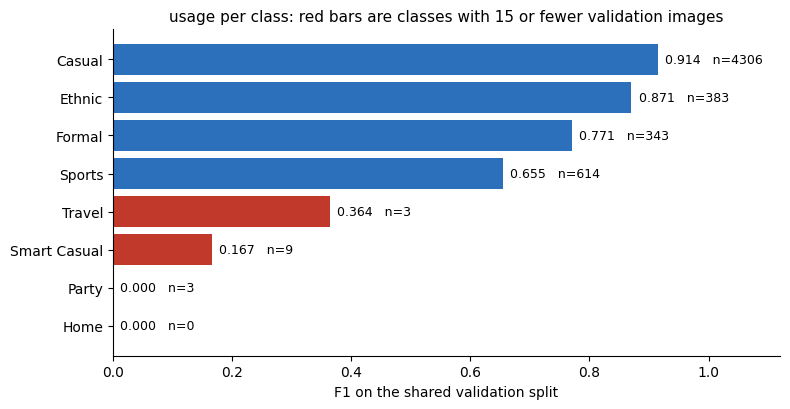

In [2]:
# Figure 1. Why no amount of tuning moved `usage`: the four rare classes hold fifteen
# validation images between them, and `Home` holds none, so its F1 is structurally
# 0.000 and macro-F1 over eight classes cannot exceed 0.875.
if ALL is None:
    print("skipped: no results directory")
else:
    d = _wide("gender_ceiling")
    d = d[d.target == "usage"].sort_values("f1")
    fig, ax = plt.subplots(figsize=(8, 4.2))
    colours = ["#c0392b" if v <= 15 else "#2c6fbb" for v in d.val_n]
    ax.barh(d["class"], d.f1, color=colours)
    for cls, f1, vn in zip(d["class"], d.f1, d.val_n):
        ax.text(f1 + 0.012, cls, f"{f1:.3f}   n={int(vn)}", va="center", fontsize=9)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("F1 on the shared validation split")
    ax.set_title("usage per class: red bars are classes with 15 or fewer "
                 "validation images", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig1_usage_label_ceiling.png", dpi=150)
    plt.show()


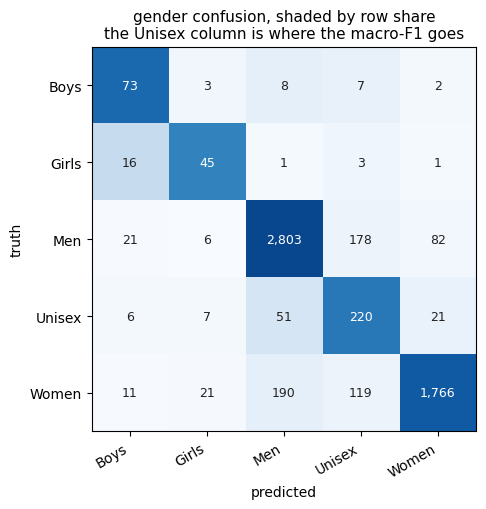

In [3]:
# Figure 2. Where `gender` loses its macro-F1. The model over-calls `Unisex`: it tags
# 178 Men and 119 Women as Unisex, which is why that column is dark off the diagonal
# and why Unisex precision is 0.417 against recall 0.721.
if ALL is None or not (FIGDIR / "gender_confusion.csv").is_file():
    print("skipped: gender_confusion.csv not found")
else:
    cm = pd.read_csv(FIGDIR / "gender_confusion.csv", index_col=0)
    frac = cm.div(cm.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    ax.imshow(frac.values, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(cm.columns)), cm.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(cm.index)), cm.index)
    ax.set_xlabel("predicted")
    ax.set_ylabel("truth")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            n = int(cm.values[i, j])
            ax.text(j, i, f"{n:,}", ha="center", va="center", fontsize=9,
                    color="white" if frac.values[i, j] > 0.5 else "#222")
    ax.set_title("gender confusion, shaded by row share\n"
                 "the Unisex column is where the macro-F1 goes", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig2_gender_confusion.png", dpi=150)
    plt.show()


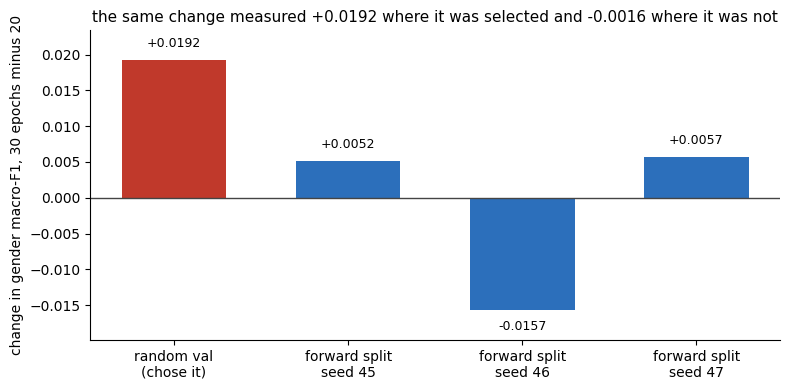

In [4]:
# Figure 3. Selection bias, measured on our own work. The sweep nominated
# `epochs=30` on the random validation split. Re-run on the forward split, which had
# never selected anything, the same change is flat and flips sign across seeds. The
# left bar is what the sweep saw; the right three are what a split it did not choose
# on saw.
if ALL is None:
    print("skipped: no results directory")
else:
    chosen = float(ALL[(ALL.source == "hyperparam_summary")
                       & (ALL.arm == "epochs=30")
                       & (ALL.metric == "gender delta")].value.iloc[0])
    ec = _wide("epochs_confirmation")
    ec["epochs"] = ec.variant.str.replace("epochs=", "", regex=False).astype(float)
    ec["seed"] = ec.rep.astype(float)
    p = ec.pivot_table(index="seed", columns="epochs", values="gender macroF1")
    paired = (p[30.0] - p[20.0])

    fig, ax = plt.subplots(figsize=(8, 4))
    labels = ["random val\n(chose it)"] + [f"forward split\nseed {int(s)}"
                                            for s in paired.index]
    values = [chosen] + list(paired.values)
    ax.bar(labels, values,
           color=["#c0392b"] + ["#2c6fbb"] * len(paired), width=0.6)
    ax.axhline(0, color="#444", lw=1)
    span = max(values) - min(min(values), 0)
    ax.set_ylim(min(min(values), 0) - 0.12 * span, max(values) + 0.12 * span)
    for i, v in enumerate(values):
        # Labels sit outside the bar on the side the bar grows, and the ylim above
        # leaves room for them: a negative label placed below the axis gets clipped.
        ax.text(i, v + (0.04 if v >= 0 else -0.04) * span, f"{v:+.4f}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    ax.set_ylabel("change in gender macro-F1, 30 epochs minus 20")
    ax.set_title(f"the same change measured {chosen:+.4f} where it was selected and "
                 f"{paired.mean():+.4f} where it was not", fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig3_selection_bias.png", dpi=150)
    plt.show()


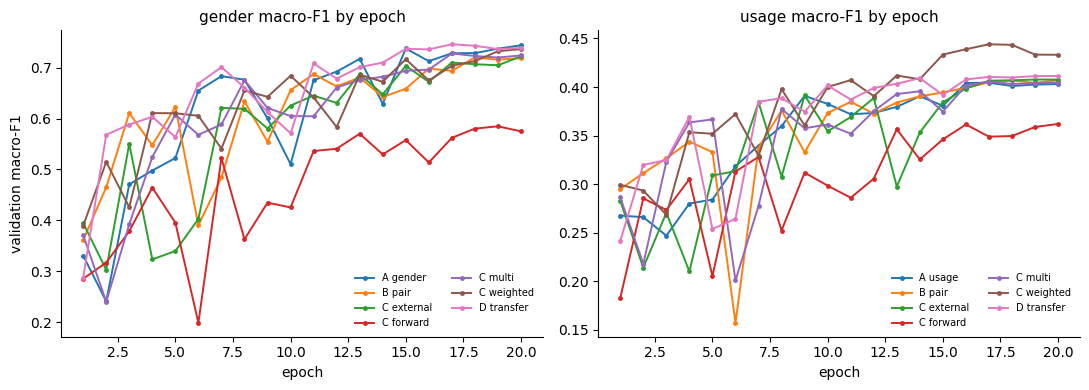

In [5]:
# Figure 4. The A/B/C/D comparison as it actually ran. Validation macro-F1 per epoch,
# same body, same 20 epochs, same rows -- only the way the labels attach differs. The
# curves are close, which is the point section 9.2 makes with numbers: the design
# differences are small next to the run-to-run spread.
if ALL is None:
    print("skipped: no results directory")
else:
    h = ALL[ALL.source == "training_history"].copy()
    h["value"] = pd.to_numeric(h.value, errors="coerce")
    h["epoch"] = pd.to_numeric(h.rep, errors="coerce")
    h["curve"] = (h.arm.fillna("") + " " + h.variant.fillna("")).str.strip()
    h = h.dropna(subset=["value", "epoch"])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    for ax, metric in zip(axes, ("val_gender", "val_usage")):
        sub = h[h.metric == metric]
        for name, g in sorted(sub.groupby("curve")):
            g = g.sort_values("epoch")
            if len(g) < 3:
                continue
            ax.plot(g.epoch, g.value, lw=1.4, marker="o", ms=2.5, label=name)
        ax.set_title(metric.replace("val_", "") + " macro-F1 by epoch", fontsize=11)
        ax.set_xlabel("epoch")
        ax.spines[["top", "right"]].set_visible(False)
        # A legend per panel, because the two panels do not hold the same runs:
        # design A trains one model per target, so "A gender" appears on the left
        # and "A usage" on the right, and a single shared legend would mislabel one.
        ax.legend(fontsize=7, ncol=2, frameon=False, loc="lower right")
    axes[0].set_ylabel("validation macro-F1")
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig4_learning_curves.png", dpi=150)
    plt.show()


### Sensitivity of the fixed hyper-parameters

Section 4 holds every hyper-parameter constant across designs A-D so that section 5
measures the design and not the tuning. That choice is only defensible if the fixed
values are not sitting on a cliff, so each was moved one factor at a time and re-run
on two seeds. `d_gender` and `d_usage` are the change against the shipped
configuration; `>noise` is whether that change exceeds the repeat-run spread measured
in section 9.2 - **0.007** on `gender` and **0.047** on `usage`.

Read it as a stability check, not a leaderboard: `lr=0.003` and `epochs=30` do clear
the `gender` noise floor, but adopting either on the strength of this validation split
is exactly the selection bias Figure 3 measures, and on `usage` no arm clears the floor
at all - which is the same ceiling section 10.5 arrives at from the oracle side.

In [6]:
# The sensitivity behind section 4's fixed values. Five one-factor changes off the
# shipped configuration (lr=1e-3, dropout=0.2, 20 epochs), two seeds each, judged
# against the repeat-run noise measured in section 9.2: 0.007 on `gender`, 0.047 on
# `usage`. A sensitivity table, not a search - nothing here selects the shipped model.
if ALL is None:
    print("skipped: no results directory")
else:
    s = ALL[ALL.source == "hyperparam_summary"]
    tbl = (s.pivot_table(index="arm", columns="metric", values="value", aggfunc="first")
             .reindex(columns=["n_seeds", "gender", "gender delta", "gender beats_noise",
                               "usage", "usage delta", "usage beats_noise"]))
    tbl.columns = ["seeds", "gender", "d_gender", "gender>noise",
                   "usage", "d_usage", "usage>noise"]
    tbl.index.name = "one-factor change"
    print(tbl.to_string())
    print()

    g = s[s.metric == "gender beats_noise"].value.tolist()
    u = s[s.metric == "usage beats_noise"].value.tolist()
    print(f"clearing the repeat-run noise floor: "
          f"gender {g.count('True')}/{len(g)} arms, usage {u.count('True')}/{len(u)} arms")

                  seeds  gender d_gender gender>noise   usage  d_usage usage>noise
one-factor change                                                                 
dropout=0.0           2  0.7413   0.0096        False  0.4439  -0.0055       False
dropout=0.4           2  0.7273  -0.0044        False  0.4423  -0.0071       False
epochs=30             2   0.751   0.0192         True  0.4551   0.0057       False
lr=0.0003             2  0.6964  -0.0353         True   0.431  -0.0184       False
lr=0.003              2  0.7489   0.0171         True  0.4505   0.0011       False

clearing the repeat-run noise floor: gender 3/5 arms, usage 0/5 arms


## 13 - References

[1] M. Sokolova and G. Lapalme, "A systematic analysis of performance measures for classification tasks," *Information Processing & Management*, vol. 45, no. 4, pp. 427-437, 2009, doi: [10.1016/j.ipm.2009.03.002](https://doi.org/10.1016/j.ipm.2009.03.002).

[2] R. Caruana, "Multitask learning," *Machine Learning*, vol. 28, pp. 41-75, 1997, doi: [10.1023/A:1007379606734](https://doi.org/10.1023/A:1007379606734).

[3] S. Ruder, "An overview of multi-task learning in deep neural networks," arXiv:1706.05098, 2017. [Online]. Available: https://arxiv.org/abs/1706.05098

[4] Y. Cui, M. Jia, T.-Y. Lin, Y. Song, and S. Belongie, "Class-balanced loss based on effective number of samples," in *Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2019, pp. 9268-9277. [Online]. Available: https://openaccess.thecvf.com/content_CVPR_2019/html/Cui_Class-Balanced_Loss_Based_on_Effective_Number_of_Samples_CVPR_2019_paper.html

[5] P. W. Koh *et al.*, "WILDS: A benchmark of in-the-wild distribution shifts," in *Proc. 38th Int. Conf. Mach. Learn. (ICML)*, vol. 139, 2021, pp. 5637-5664. [Online]. Available: https://proceedings.mlr.press/v139/koh21a.html

[6] G. C. Cawley and N. L. C. Talbot, "On over-fitting in model selection and subsequent selection bias in performance evaluation," *J. Mach. Learn. Res.*, vol. 11, pp. 2079-2107, 2010. [Online]. Available: https://www.jmlr.org/papers/v11/cawley10a.html


[7] A. K. Menon, S. Jayasumana, A. S. Rawat, H. Jain, A. Veit, and S. Kumar,
"Long-tail learning via logit adjustment," in *Proc. Int. Conf. Learn.
Representations (ICLR)*, 2021. [Online]. Available:
https://arxiv.org/abs/2007.07314